# Coursework 1: Chest X-ray (100 marks)

In this coursework, you will be working with the Kaggle [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data) dataset. You will analyze the dataset, and train deep learning models to classify whether an x-ray exhibits pneumonia.


The coursework is structured as follows:

1. Data Analysis: 5 marks
2. Data Preparation: 5 marks
3. Training a Baseline: 30 marks
4. Improving the Baseline: 50 marks
5. Evaluating on the Test Set: 10 marks

In each question will require you tocode up a solution, and to briefly explain and discuss your choices and results.

__IMPORTANT__
* Pretrained models are __NOT__ allowed. You will recieve __0__ marks for any use of pretrained models.
* The use of LLM/AI support including writing and coding aligns to the UCL guidelines. This includes the use of code prompts and Gemini in Google Collab

Here are some additional tips:
- We recommend using weights and biases to log your training runs. This will allow you to easily compare previous runs if needed.
- Ensure your results are reproducable - we may rerun your notebook to check for this. Points will be lost if results are not reproducable.
- We recommend factorizing your code in places where you will be repeatedly using the same functionaility. For example, if you are training multiple models, consider using a common training loop function.
- Your code and results and discussions should be concise, well-presented, and easy to read. Each question has a certain portion of marks going towards this.
- Ensure you correctly use the train, validation, and test set throughout. You should only ever use the test set once - for the final evaluation.
- Consider saving your models so you can reload previous models for the final evaluation
- Ensure it is clear to the reader what any plots / figures are presenting. I.e., label axes, include titles, ensure it is clear what experiment it is from (what model / design choices, etc.)
- Google Collab restricts the amount of GPU time available. Consider debugging code, using a subset of data, on CPU compute

In [1]:
!pip install kaggle
!pip install wandb

If you get the following error when running the import cell below this description:


```
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/
```
You will need to create a kaggle account, and navigate to https://www.kaggle.com/me/account. Navigate to "API" and create a new token. This will automatically download a json file called "kaggle.json".

Run the following code, replacing the "INSERT JSON HERE TEXT" with the contents of the json that you downloaded.

```
!mkdir /root/.config/kaggle
!touch /root/.config/kaggle/kaggle.json

api_token = INSERT JSON HERE TEXT

import json

with open('/root/.config/kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 /root/.config/kaggle/kaggle.json
```

INSERT JSON HERE TEXT should be something of the form:
```
{"username":"XXX","key":"XXX"}
```

In [2]:
!mkdir /root/.config/kaggle
!touch /root/.config/kaggle/kaggle.json

api_token = {"username":"harryfyjiswalker","key":"0c550fda84d2bc7ea92b82b465fca15a"}

import json

with open('/root/.config/kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 /root/.config/kaggle/kaggle.json

In [3]:
import os
import random
import shutil
import kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
import matplotlib.pyplot as plt
import numpy as np

import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import models, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import wandb

In [4]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load and Re-split the Raw Data

The original data is poorly split, so we will resplit it here. Do NOT edit this code.

In [5]:
# Hyperparameters
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1  # This is implicitly defined as 1 - (TRAIN_SPLIT + VAL_SPLIT)

In [6]:
# Set up the Kaggle API
api = KaggleApi()
api.authenticate()

# Specify the dataset
dataset = "paultimothymooney/chest-xray-pneumonia"

# Specify the download path
download_path = "chest_xray_dataset"

# Check if the dataset is already downloaded
if os.path.exists(os.path.join(download_path, "chest_xray")):
    print(f"Dataset already exists at {download_path}. Skipping download.")
else:
    # Create the download directory if it doesn't exist
    os.makedirs(download_path, exist_ok=True)

    # Download the dataset
    print(f"Downloading {dataset} to {download_path}")
    api.dataset_download_files(dataset, path=download_path, unzip=True)
    print("Download complete!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
Download complete!


In [7]:
# Re-split data
dataset_path = os.path.join(download_path, "chest_xray")
new_dataset_path = "chest_xray_dataset_new_split"

if not os.path.exists(new_dataset_path):
    # Create new directory structure
    for split in ['train', 'val', 'test']:
        for cls in ['NORMAL', 'PNEUMONIA']:
            os.makedirs(os.path.join(new_dataset_path, split, cls), exist_ok=True)

    for cls in ['NORMAL', 'PNEUMONIA']:
        all_files = []
        for split in ['train', 'val', 'test']:
            source_folder = os.path.join(dataset_path, split, cls)
            files = os.listdir(source_folder)
            all_files.extend([(file, source_folder) for file in files])

        # Sort files to ensure consistent order before shuffling
        all_files.sort()

        # Create a new Random object with the seed
        rng = random.Random(42)

        # Use the shuffle method of the Random object
        rng.shuffle(all_files)

        total_files = len(all_files)
        train_end = int(total_files * TRAIN_SPLIT)
        val_end = int(total_files * (TRAIN_SPLIT + VAL_SPLIT))

        train_files = all_files[:train_end]
        val_files = all_files[train_end:val_end]
        test_files = all_files[val_end:]

        for split, file_list in [('train', train_files), ('val', val_files), ('test', test_files)]:
            for file, source_folder in file_list:
                source = os.path.join(source_folder, file)
                dest = os.path.join(new_dataset_path, split, cls, file)
                shutil.copy(source, dest)

    print(f"Data re-split complete. New dataset location: {new_dataset_path}")
else:
    print(f"Re-split dataset already exists at {new_dataset_path}")

Data re-split complete. New dataset location: chest_xray_dataset_new_split


# Question 1: Data Analysis (5 marks)

Perform some basic analysis of the statistics of the dataset.

Try to spot anything that may impact how you will design your deep learning classifier and training.

We'd expect to see:
* Analysis of labels (target variable);
* Analysis of input features;

If you do spot anything, briefly explain **how you think it may impact training**.


In [8]:
# Collect dataset statistics
splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

stats = {split: {cls: 0 for cls in ['NORMAL', 'PNEUMONIA']} for split in ['train', 'val', 'test']}
for split in splits:
    for cls in classes:
        path = os.path.join(new_dataset_path, split, cls)
        stats[split][cls] = len(os.listdir(path))


TRAIN Set (Total: 4684):
  NORMAL: 1266 (27.03%)
  PNEUMONIA: 3418 (72.97%)
  PNEUMONIA to NORMAL Ratio: 2.70:1

VAL Set (Total: 585):
  NORMAL: 158 (27.01%)
  PNEUMONIA: 427 (72.99%)
  PNEUMONIA to NORMAL Ratio: 2.70:1

TEST Set (Total: 587):
  NORMAL: 159 (27.09%)
  PNEUMONIA: 428 (72.91%)
  PNEUMONIA to NORMAL Ratio: 2.69:1

Dataset Size: 5856


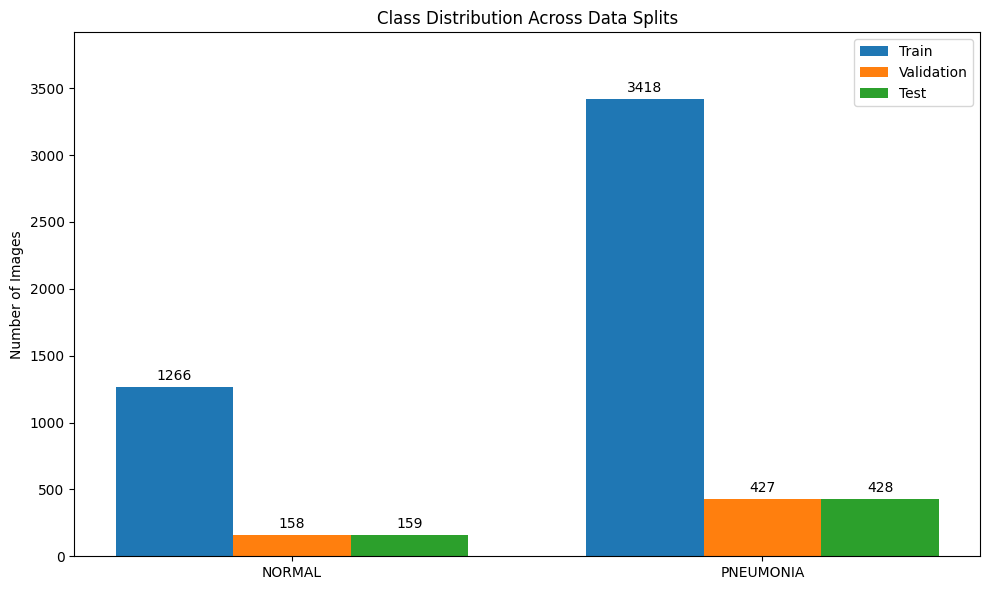

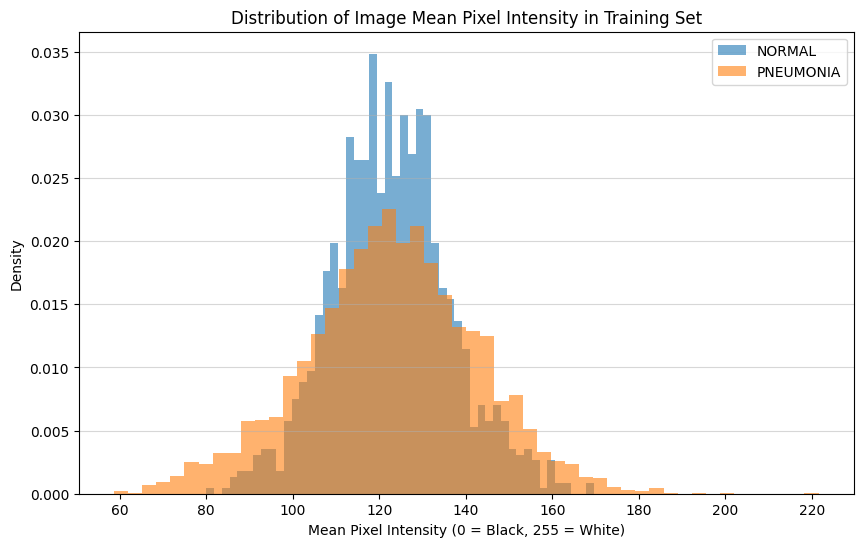

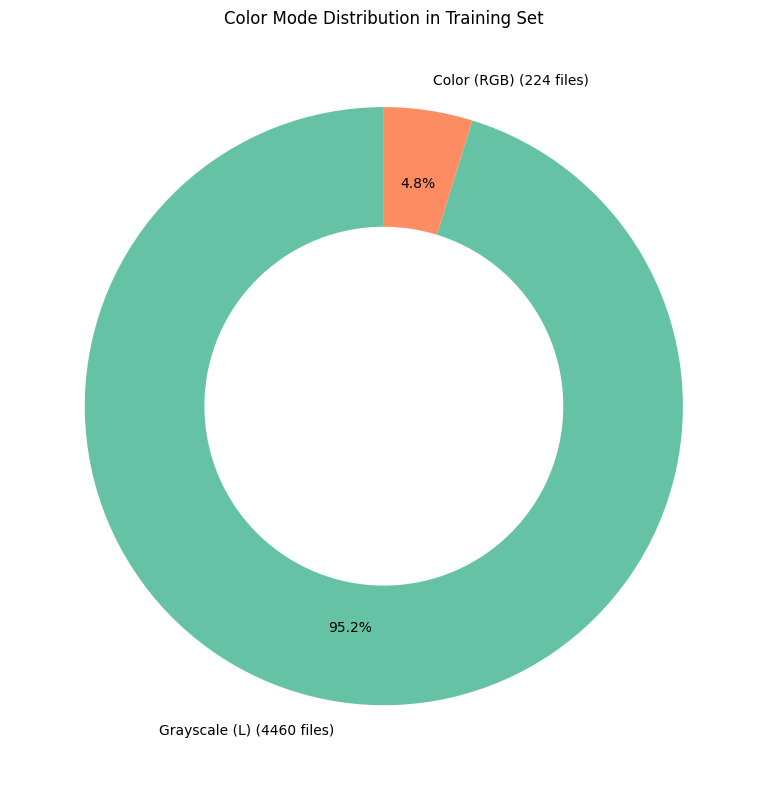


NORMAL Sample 1:
  Raw Image Size (W, H): (1438, 1059)
  Color Mode (PIL): L

NORMAL Sample 2:
  Raw Image Size (W, H): (2064, 1951)
  Color Mode (PIL): L

PNEUMONIA Sample 3:
  Raw Image Size (W, H): (1104, 848)
  Color Mode (PIL): L

PNEUMONIA Sample 4:
  Raw Image Size (W, H): (1827, 1044)
  Color Mode (PIL): L


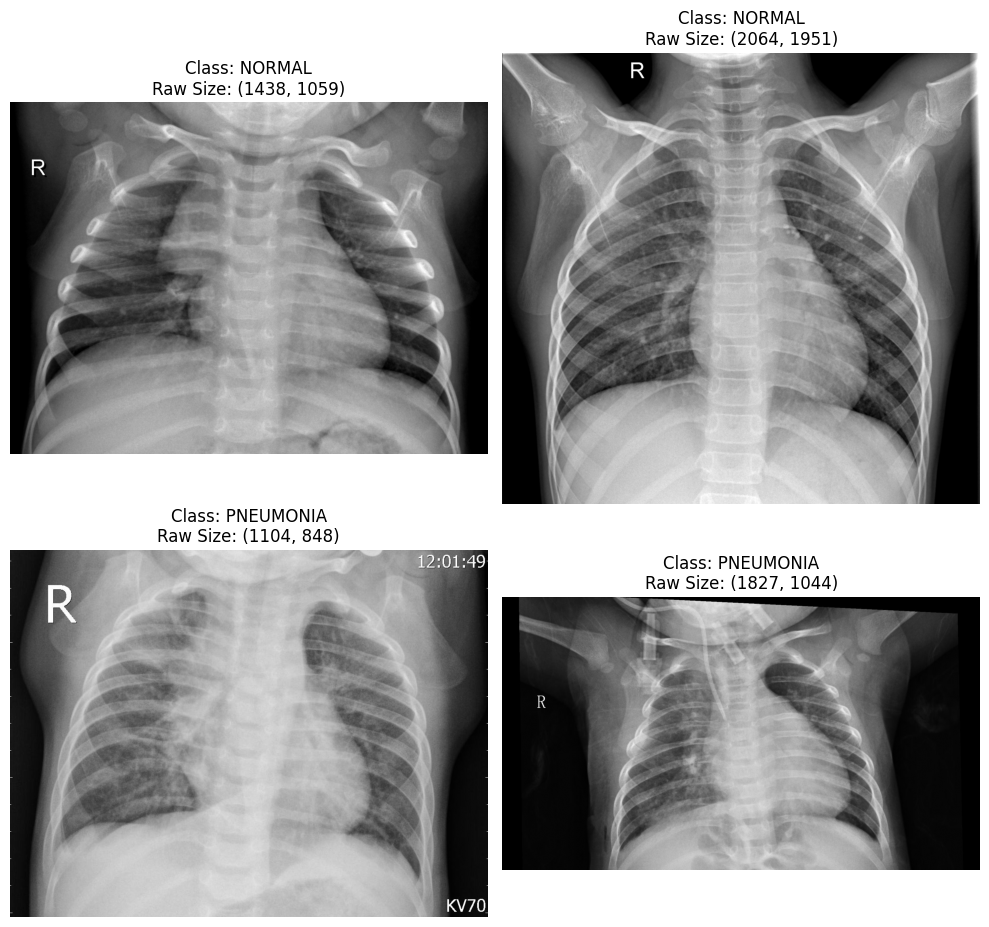

In [11]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import warnings
from collections import defaultdict

total_files = 0
for split in splits:
    normal_count = stats[split]['NORMAL']
    pneumonia_count = stats[split]['PNEUMONIA']
    total_split = normal_count + pneumonia_count
    total_files += total_split

    # Calculate imbalance ratio (PNEUMONIA to NORMAL)
    if normal_count > 0:
        ratio = pneumonia_count / normal_count
    else:
        ratio = float('inf')

    normal_perc = (normal_count / total_split) * 100
    pneumonia_perc = (pneumonia_count / total_split) * 100

    print(f"\n{split.upper()} Set (Total: {total_split}):")
    print(f"  NORMAL: {normal_count} ({normal_perc:.2f}%)")
    print(f"  PNEUMONIA: {pneumonia_count} ({pneumonia_perc:.2f}%)")
    print(f"  PNEUMONIA to NORMAL Ratio: {ratio:.2f}:1")

print(f"\nDataset Size: {total_files}")

# Plotting Class Distribution
labels = ['NORMAL', 'PNEUMONIA']
train_counts = [stats['train']['NORMAL'], stats['train']['PNEUMONIA']]
val_counts = [stats['val']['NORMAL'], stats['val']['PNEUMONIA']]
test_counts = [stats['test']['NORMAL'], stats['test']['PNEUMONIA']]

x = np.arange(len(labels))
width = 0.25

fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
rects1 = ax_bar.bar(x - width, train_counts, width, label='Train')
rects2 = ax_bar.bar(x, val_counts, width, label='Validation')
rects3 = ax_bar.bar(x + width, test_counts, width, label='Test')

ax_bar.set_ylabel('Number of Images')
ax_bar.set_title('Class Distribution Across Data Splits')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels)
ax_bar.legend()
ax_bar.set_ylim(0, max(train_counts) + 500)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax_bar.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show() # Display the bar chart

train_path = os.path.join(new_dataset_path, 'train')
dataset_path_for_sampling = new_dataset_path
# Analysing inputs - looking at size, channel (RGB, grayscale), mean pixel intensity, and printing samples for inspection

def get_brightness_distribution(base_path, classes):
    """Calculates the mean pixel intensity for all images in the specified classes."""
    brightness_data = {cls: [] for cls in classes}

    if not os.path.exists(base_path):
        return None

    for cls in classes:
        class_path = os.path.join(base_path, cls)
        if not os.path.exists(class_path):
            continue

        files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]

        for filename in files:
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert('L')
                img_array = np.array(img)
                mean_brightness = np.mean(img_array)
                brightness_data[cls].append(mean_brightness)

            except Exception as e:
                warnings.warn(f"Could not process image {img_path}: {e}")

    return brightness_data

brightness_data = get_brightness_distribution(train_path, classes)

if brightness_data and any(brightness_data[cls] for cls in classes):
    fig_hist, ax_hist = plt.subplots(figsize=(10, 6))

    ax_hist.hist(brightness_data['NORMAL'], bins=50, alpha=0.6, label='NORMAL', density=True)
    ax_hist.hist(brightness_data['PNEUMONIA'], bins=50, alpha=0.6, label='PNEUMONIA', density=True)

    ax_hist.set_title('Distribution of Image Mean Pixel Intensity in Training Set')
    ax_hist.set_xlabel('Mean Pixel Intensity (0 = Black, 255 = White)')
    ax_hist.set_ylabel('Density')
    ax_hist.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

#For counting number of rgb etc
def analyze_color_modes(base_path, classes):
    mode_counts = defaultdict(int)

    if not os.path.exists(base_path):
        return mode_counts

    for cls in classes:
        class_path = os.path.join(base_path, cls)
        if not os.path.exists(class_path):
            continue

        files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]

        for filename in files:
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path)

                if img.mode == 'L':
                    mode_counts['Grayscale (L)'] += 1
                elif img.mode == 'RGB':
                    mode_counts['Color (RGB)'] += 1
                elif img.mode == 'RGBA':
                    mode_counts['Color (RGBA)'] += 1
                elif img.mode == 'CMYK':
                    mode_counts['Color (CMYK)'] += 1
                else:
                    mode_counts[f'Other ({img.mode})'] += 1

            except Exception as e:
                warnings.warn(f"Could not open image {img_path}: {e}")

    return dict(mode_counts)

color_mode_counts = analyze_color_modes(train_path, classes)
total_images_mode = sum(color_mode_counts.values())

if total_images_mode > 0:

    mode_labels = []
    mode_percents = []

    for mode, count in color_mode_counts.items():
        if count > 0:
            percent = (count / total_images_mode) * 100
            mode_labels.append(f'{mode} ({count} files)')
            mode_percents.append(percent)

    fig_mode, ax_mode = plt.subplots(figsize=(8, 8))

    wedges, texts, autotexts = ax_mode.pie(
        mode_percents,
        labels=mode_labels,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.4),
        pctdistance=0.75,
        colors=plt.cm.Set2.colors
    )

    centre_circle = plt.Circle((0,0), 0.20, fc='white')
    ax_mode.add_artist(centre_circle)

    ax_mode.set_title('Color Mode Distribution in Training Set')

    plt.tight_layout()
    plt.show()


def get_sample_paths(base_path, split, num_samples=2):
    samples = {}
    path_base = os.path.join(base_path, split)
    if not os.path.exists(path_base):
        return None

    for cls in classes:
        path = os.path.join(path_base, cls)
        if not os.path.exists(path):
            continue
        files = [f for f in os.listdir(path) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
        random.seed(42)
        selected_files = random.sample(files, min(num_samples, len(files)))
        samples[cls] = [os.path.join(path, f) for f in selected_files]
    return samples

# Get sample paths
sample_paths = get_sample_paths(dataset_path, split='train', num_samples=2)

if sample_paths and any(sample_paths[cls] for cls in classes):

    # Calculate number of required subplots
    total_samples_to_show = sum(len(paths) for paths in sample_paths.values())

    if total_samples_to_show > 0:
        rows = 2
        cols = (total_samples_to_show + 1) // 2

        fig_sample, axes_sample = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        axes_sample = axes_sample.flatten()
        sample_count = 0

        for cls, paths in sample_paths.items():
            for path in paths:
                img = Image.open(path)

                ax = axes_sample[sample_count]
                ax.imshow(img, cmap='gray')
                ax.set_title(f"Class: {cls}\nRaw Size: {img.size}")
                ax.axis('off')

                # Print properties
                print(f"\n{cls} Sample {sample_count + 1}:")
                print(f"  Raw Image Size (W, H): {img.size}")
                print(f"  Color Mode (PIL): {img.mode}")

                sample_count += 1

        # Turn off any unused subplots
        for i in range(sample_count, len(axes_sample)):
            axes_sample[i].axis('off')

        plt.tight_layout()
        plt.show() # Display the sample image grid

**(a)**

**Analysis of Labels:** The dataset exhibits a clear skew towards the pneumonia class across all splits, with a consistent ratio of approximately 1:2.7 Normal:Pneumonia. For each of the training, validation, and test sets - with sizes 4684, 585, and 587, respectively - approximately 73% are PNEUMONIA samples. This is displayed numerically above in the first print out, and visually in the second (bar chart) print out.

As such, the label distribution exhibits noticeable imbalance. In the context of binary medical image classification, if untreated this can bias the model towards predicting the dominant class, inflating accuracy while disregarding the minority NORMAL class (low NORMAL recall). This would render the model useless clinically by producing many a high rate of false positives.

This observation suggests that the classifier may benefit from a class-weighted loss function to force the model to treat the two classes equally despite the imbalance, as well as from mechanisms that stabilise training under imbalance, such as data augmentation or regularisation. These will be explored later.

The imbalance also motivates the use of evaluation metrics beyond accuracy, which can be misleading in the context of imbalanced datasets - here, for example, an accuracy of 73% could be achieved by predicting everything as PNEUMONIA, completely defeating the point of the model. Most common in this context are Sensitivity (Pneumonia Recall) and Specificity (Normal Recall) - these are used in this project to simultaneously ensure performance on the minority class is fairly evaluated and to enable comparison with current literature on this topic.

**Analysis of Input Features:**
- The dataset is not uniformly grayscale: as visualised in the donut plot above, while the vast majority are 1-channel grayscale images (95.2%), the remaining 4.8% are 3-channel RGB images. To ensure model compatibility with the input, we will need a fixed number of input channels. Architectures generally optimised for 3-channel input so it is chosen here; standardising all images into this three-channel format will be necessary in preprocessing.[1][2]
- The final two printouts above demonstrate that the raw image dimensions are varied. The images will need to be resized to a uniform size (224x224 is standard in this context[1][2]) in preprocessing to ensure a consistent input to the model.
- Mean pixel intensity distribution is roughly symmetric - there is no consistent bias towards more dark or bright images across dataset, but a large variance exists. This might introduce issues of spurious correlations between pathology with contrast/ brightness levels rather than clinical features - augmentation may be an appropriate mitigation strategy.
- After standarisation to three channels and resizing, all images will need to be normalised to stabilise gradient descent during training, which helps to promote faster and more reliable convergence.
- It is also noted that chest X-ray images are high-dimensional inputs and the information in them is spatially structured. The important visual characteristics needed for diagnosis (e.g. opacities, lung boundaries) are local (found in specific small regions) and hierarchical (built up from simpler elements to form complex structures). Convolutional Neural Networks focus on small, local areas and can detect features regardless of where they appear in an image (they are translationally invariant), so are a strong choice for this task and are commonly employed in the associated literature. CNNs will therefore form the basis of the modelling in this coureswork.[1][3][4]

*[1] S. K.P, S. M. K., D. Agarwal and M. Samuel, "Pneumonia Detection using Chest X-Ray Images: A Convolutional Neural Network with Skip Connection Approach," 2025 International Conference on Ambient Intelligence in Health Care (ICAIHC), Raipur Chattisgarh, India, 2025, pp. 1-6, doi: 10.1109/ICAIHC64101.2025.10956256.*

*[2] S. Phine, "Pneumonia Classification Using Deep Learning VGG19 Model," 2023 IEEE Conference on Computer Applications (ICCA), Yangon, Myanmar, 2023, pp. 67-71, doi: 10.1109/ICCA51723.2023.10181954.*

*[3] Hasan MdR, Ullah SMA, Karim MdE. An Effective Framework for Identifying Pneumonia in Healthcare Using a Convolutional Neural Network. In: Proceedings of the 2023 International Conference on Electrical, Computer and Communication Engineering (ECCE). pp. 1-6. doi: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=10101548*

*[4] Aich S, Kim HC, Chakraborty S, et al. Detection of Pneumonia from Chest X-Rays using a Convolutional Neural Network Architecture. Available online: http://www.dbpia.co.kr/journal/articleDetail?nodeId=NODE08747418 (accessed on 23 January 2025).*

# Question 2: Data Preparation (5 marks)

Here, you should load the dataset into torch dataloaders, performing any preprocessing required in the process.

Within the ChestXrayDataset class, the root_dir parameter is a string defining the directory containing the "train", "val" and "test" folders.

In [9]:
dataset_path = "chest_xray_dataset_new_split"
batch_size = 32 #Chosen as a standard, stable batch size

In [10]:
class ChestXrayDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        ########################################################################
        #                              YOUR CODE HERE                          #
        ########################################################################

        self.root_dir = os.path.join(root_dir, split)
        self.transform = transform
        self.split = split
        self.classes = ['NORMAL', 'PNEUMONIA']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        self.images = []
        for cls in self.classes:
            class_path = os.path.join(self.root_dir, cls)
            for filename in os.listdir(class_path):
                if filename.endswith(('.jpeg', '.jpg', '.png')):
                    self.images.append((os.path.join(class_path, filename), self.class_to_idx[cls]))

        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        ########################################################################
        #                              YOUR CODE HERE                          #
        ########################################################################
        img_path, label = self.images[idx]

        # Load as grayscale to handle all images in same way, then convert to RGB
        image = Image.open(img_path).convert('L') # Convert to Grayscale

        # Convert to 3-channel
        image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32) # Use float32 for BCEWithLogitsLoss

        return image, label


        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

In [11]:
# Define data transforms
        ########################################################################
        #                              YOUR CODE HERE                          #
        ########################################################################
# ImageNet means and stds are used as a standard starting point for baseline
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224 # Size used most commonly in literature in this context

train_transform = transforms.Compose([
    # Standard preprocessing
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), #resizing
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), #normalisation

    # geometric augmentation - rotations and flipping
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
])

val_test_transform = transforms.Compose([
    # Only deterministic steps for validation/test
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

In [12]:
        ########################################################################
        #                              YOUR CODE HERE                          #
        ########################################################################
# Create datasets
train_dataset = ChestXrayDataset(root_dir=dataset_path, split='train', transform=train_transform)
val_dataset = ChestXrayDataset(root_dir=dataset_path, split='val', transform=val_test_transform)
test_dataset = ChestXrayDataset(root_dir=dataset_path, split='test', transform=val_test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)



        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

# Print dataset sizes
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

# Print batch shapes
images, labels = next(iter(train_loader))
print(f"Batch Image Tensor Shape: {images.shape}")
print(f"Batch Label Tensor Shape: {labels.shape}")

Training set size: 4684
Validation set size: 585
Test set size: 587
Batch Image Tensor Shape: torch.Size([32, 3, 224, 224])
Batch Label Tensor Shape: torch.Size([32])


**(a)**

- Grayscale to RGB Conversion: the images are first loaded in grayscale (by Image.convert('L')) and then converted to 3-channel RGB (Image.convert('RGB')). As noted above, standard CNN architectures are typically configured to accept a 3-channel input, and this is also standard practice in literature focusing on this data set [1][2]; the conversion ensures compatibility with these standard architectures while preserving the original image information.
- All images are resized to 224 x 244. This is a standard input size for many CNN architectures and, again, is commonly seen in literature that trains models on this specific dataset.[1][2]
- All images are normalised using the ImageNet mean and standard deviation values.[2] As noted, this helps to to stabilise gradient descent during training, which supports faster and more reliable convergence.
- It has previously been noted that without data augmentation, the model tends to overfit.[3] For the simple baseline, I decide to only implement geometric augmentations (RandomHorizontalFlip, RandomRotation (5)); more complex augmentations e.g. jittering will be explored in the model optimisation section. The augmentation is applied only to the training set to improve generalisation without leaking information into validation or test data.
- PyTorch DataLoaders are used to enable efficient mini-batch training (a batch size of 32 is chosen as a standard, scalable batch size).

*[1] S. K.P, S. M. K., D. Agarwal and M. Samuel, "Pneumonia Detection using Chest X-Ray Images: A Convolutional Neural Network with Skip Connection Approach," 2025 International Conference on Ambient Intelligence in Health Care (ICAIHC), Raipur Chattisgarh, India, 2025, pp. 1-6, doi: 10.1109/ICAIHC64101.2025.10956256.*

*[2] S. Phine, "Pneumonia Classification Using Deep Learning VGG19 Model," 2023 IEEE Conference on Computer Applications (ICCA), Yangon, Myanmar, 2023, pp. 67-71, doi: 10.1109/ICCA51723.2023.10181954.*

*[3] Mathur, M. (2020) Pneumonia Detection using CNN (92.6% Accuracy). Kaggle. Available at: https://www.kaggle.com/code/madz2000/pneumonia-detection-using-cnn-92-6-accuracy/notebook (Accessed: 6 December 2025).*



# Question 3: Training a Baseline (30 marks)

You will now establish an initial baseline model and training procedure. This should be as simple as possible, without using any elaborate design choices, whilst still obtaining reasonable performance (i.e., at least better than random chance). You will attempt to improve upon this baseline in later questions.

When answering this question, consider what makes a good baseline:
* Easily converges;
* Easy to implement;
* Established architectural components that have proved well suited to the data-type and problem.
* Obtains reasonable performance e.g, better than random guess

You will be required to explain your design choices, and to present and discuss you results.

The code below is a suggested structure to guide you. You are free to deviate from this __however, it must be obvious to the marker__:
* What the final proposed baseline model is (in terms of architecture);
* What the performance of the baseline model is and how the model has been trained;
* What your written justification and discussion is;



In [13]:
#Calculate pos_weight = Count_Negative_Examples / Count_Positive_Examples
TRAIN_NORMAL_COUNT = 1266
TRAIN_PNEUMONIA_COUNT = 3418
POS_WEIGHT_VAL = TRAIN_NORMAL_COUNT / TRAIN_PNEUMONIA_COUNT
print(f"pos_weight (Normal/Pneumonia): {POS_WEIGHT_VAL:.4f}")

pos_weight (Normal/Pneumonia): 0.3704


In [14]:
num_epochs = 30 #fast convergence for simple model
use_wandb = True  # using wandb for logging
lr = 1e-3 #standard for Adam optmiser
POS_WEIGHT_VAL = 0.3704 #derived above

In [15]:
# Define the model
class SimpleModel(nn.Module):
    def __init__(self, num_classes=1):
        super(SimpleModel, self).__init__()
        ########################################################################
        #                              YOUR CODE HERE                          #
        ########################################################################

        # sequential CNN with 3 convolutional blocks
        self.features = nn.Sequential(
            # Block 1: 224x224 -> 112x112
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: 112x112 -> 56x56
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: 56x56 -> 28x28
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Classification head input size is 64 channels * 1*1 (after avgpool)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), # Simple regularization
            nn.Linear(64, num_classes) # outputting a single logit for binary classification
        )

        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [16]:
def calculate_class_accuracy(outputs, labels):
    ########################################################################
    #                              YOUR CODE HERE                          #
    ########################################################################

    # Applying sigmoid and round to get binary predictions
    preds = torch.round(torch.sigmoid(outputs))

    # Calculating TPs, TNs etc. (Labels: 1=Pneumonia (Positive), 0=Normal (Negative))
    labels_int = labels.int()
    preds_int = preds.int()

    TP = ((preds_int == 1) & (labels_int == 1)).sum().item()
    TN = ((preds_int == 0) & (labels_int == 0)).sum().item()
    FP = ((preds_int == 1) & (labels_int == 0)).sum().item()
    FN = ((preds_int == 0) & (labels_int == 1)).sum().item()

    # Sensitivity (Recall for Positive/Pneumonia class)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    # Specificity (Recall for Negative/Normal class)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

    # Overall Accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0.0

    # Storing class accuracies as a dictionary
    class_accuracies = {
        'Pneumonia_Recall': sensitivity,
        'Normal_Recall': specificity
    }

    return accuracy, class_accuracies

    ########################################################################
    #                             END OF YOUR CODE                         #
    ########################################################################

In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device='cuda', use_wandb=True):

        ########################################################################
        #                              YOUR CODE HERE                          #
        ########################################################################

    # Initialise wandb for logging
    wandb.init(project="COMP0188_CW1_Baseline", config={
        "num_epochs": num_epochs,
        "learning_rate": optimizer.param_groups[0]['lr'],
        "batch_size": train_loader.batch_size,
        "model": "SimpleModel_Baseline",
        "loss_weight": criterion.pos_weight.item() if hasattr(criterion, 'pos_weight') else 1.0
    })
    wandb.watch(model, criterion, log="all", log_freq=10)

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    train_class_accuracies = {'Pneumonia_Recall': [], 'Normal_Recall': []}
    val_class_accuracies = {'Pneumonia_Recall': [], 'Normal_Recall': []}

    best_val_accuracy = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # Defining accumulators for class metrics
        tp, tn, fp, fn = 0, 0, 0, 0
        total_samples = 0

        # Training loop
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)"):
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1) # Add channel dimension for labels

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Calculating batch metrics
            preds = torch.round(torch.sigmoid(outputs))
            labels_int = labels.int()
            preds_int = preds.int()

            tp += ((preds_int == 1) & (labels_int == 1)).sum().item()
            tn += ((preds_int == 0) & (labels_int == 0)).sum().item()
            fp += ((preds_int == 1) & (labels_int == 0)).sum().item()
            fn += ((preds_int == 0) & (labels_int == 1)).sum().item()

            total_samples += labels.size(0)

        # Calculating epoch metrics
        epoch_loss = running_loss / total_samples
        epoch_accuracy = (tp + tn) / total_samples if total_samples > 0 else 0.0

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        train_class_accuracies['Pneumonia_Recall'].append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        train_class_accuracies['Normal_Recall'].append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)


        # Validation loop
        model.eval()
        val_loss = 0.0
        val_tp, val_tn, val_fp, val_fn = 0, 0, 0, 0
        val_total_samples = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Val)"):
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)

                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                # Calculating batch metrics
                preds = torch.round(torch.sigmoid(outputs))
                labels_int = labels.int()
                preds_int = preds.int()

                val_tp += ((preds_int == 1) & (labels_int == 1)).sum().item()
                val_tn += ((preds_int == 0) & (labels_int == 0)).sum().item()
                val_fp += ((preds_int == 1) & (labels_int == 0)).sum().item()
                val_fn += ((preds_int == 0) & (labels_int == 1)).sum().item()

                val_total_samples += labels.size(0)

        epoch_val_loss = val_loss / val_total_samples
        epoch_val_accuracy = (val_tp + val_tn) / val_total_samples if val_total_samples > 0 else 0.0

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)

        val_pneumonia_recall = val_tp / (val_tp + val_fn) if (val_tp + val_fn) > 0 else 0.0
        val_normal_recall = val_tn / (val_tn + val_fp) if (val_tn + val_fp) > 0 else 0.0

        val_class_accuracies['Pneumonia_Recall'].append(val_pneumonia_recall)
        val_class_accuracies['Normal_Recall'].append(val_normal_recall)


        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")
        print(f"  Train Recall (Pneumonia/Normal): {train_class_accuracies['Pneumonia_Recall'][-1]:.4f}/{train_class_accuracies['Normal_Recall'][-1]:.4f}")
        print(f"  Val Recall (Pneumonia/Normal): {val_pneumonia_recall:.4f}/{val_normal_recall:.4f}")

        # Wandb logging
        wandb.log({
            "Train/Loss": epoch_loss,
            "Train/Accuracy": epoch_accuracy,
            "Train/Pneumonia_Recall": train_class_accuracies['Pneumonia_Recall'][-1],
            "Train/Normal_Recall": train_class_accuracies['Normal_Recall'][-1],
            "Val/Loss": epoch_val_loss,
            "Val/Accuracy": epoch_val_accuracy,
            "Val/Pneumonia_Recall": val_pneumonia_recall,
            "Val/Normal_Recall": val_normal_recall
        })

        # Save best model based on validation accuracy
        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy
            best_model_state = model.state_dict()

    wandb.finish()

    ########################################################################
    #                             END OF YOUR CODE                         #
    ########################################################################

    return train_losses, train_accuracies, val_losses, val_accuracies, train_class_accuracies, val_class_accuracies, best_model_state

In [18]:
def plot_training_curves(train_losses, train_accuracies, val_losses, val_accuracies, train_class_accuracies, val_class_accuracies):

    ########################################################################
    #                              YOUR CODE HERE                          #
    ########################################################################
    epochs = range(1, len(train_losses) + 1)

    # Loss Curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.title('Baseline Model: Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Overall Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Validation Accuracy')
    plt.title('Baseline Model: Overall Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Class-Specific Recall Curves
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, val_class_accuracies['Pneumonia_Recall'], label='Val Sensitivity (Pneumonia Recall)')
    plt.plot(epochs, val_class_accuracies['Normal_Recall'], label='Val Specificity (Normal Recall)')
    plt.title('Baseline Model: Validation Recall (Sensitivity/Specificity) Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Recall / Specificity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    ########################################################################
    #                             END OF YOUR CODE                         #
    ########################################################################

Epoch 1/30 (Val): 100%|██████████| 19/19 [00:08<00:00,  2.12it/s]


Epoch 1/30: Train Loss: 0.2574, Train Acc: 0.7635, Val Loss: 0.2395, Val Acc: 0.7385
  Train Recall (Pneumonia/Normal): 0.7159/0.8918
  Val Recall (Pneumonia/Normal): 0.6581/0.9557


Epoch 2/30 (Val): 100%|██████████| 19/19 [00:08<00:00,  2.37it/s]


Epoch 2/30: Train Loss: 0.2200, Train Acc: 0.8185, Val Loss: 0.2174, Val Acc: 0.8701
  Train Recall (Pneumonia/Normal): 0.8008/0.8665
  Val Recall (Pneumonia/Normal): 0.9321/0.7025


Epoch 3/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  1.98it/s]


...

Epoch 29/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.08it/s]


Epoch 29/30: Train Loss: 0.1524, Train Acc: 0.8843, Val Loss: 0.1042, Val Acc: 0.8906
  Train Recall (Pneumonia/Normal): 0.8774/0.9028
  Val Recall (Pneumonia/Normal): 0.8595/0.9747


Epoch 30/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.04it/s]

Epoch 30/30: Train Loss: 0.1390, Train Acc: 0.8924, Val Loss: 0.0876, Val Acc: 0.9333
  Train Recall (Pneumonia/Normal): 0.8853/0.9115
  Val Recall (Pneumonia/Normal): 0.9274/0.9494


Train/Accuracy,▁▄▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█▇███
Train/Loss,█▆▅▄▄▄▄▄▄▃▃▃▂▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁
Train/Normal_Recall,▅▁▂▃▄▄▂▃▄▅▅▆▆▄▅▆▅▅▆▇▆█▇▆█▆▆█▇█
Train/Pneumonia_Recall,▁▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████
Val/Accuracy,▄▇▇▆▇▆▃▇▄▅█▆█▇▅▂▆█████▁▇▇██▂▇█
Val/Loss,▅▄▃▃▄▃▇▅▅▄▂▃▂▂▄▇▂▂▂▂▂▂█▂▂▂▂█▁▁
Val/Normal_Recall,▇▃▆█▂██▁██▆█▆▇███▇▆▆▇▅██▇▇▇██▇
Val/Pneumonia_Recall,▄▇▇▅█▅▃█▄▅▇▆▇▆▅▂▆▇▇▇▇█▁▆▇▇▇▂▆▇
Train/Accuracy,0.8924
Train/Loss,0.13897
Train/Normal_Recall,0.91153


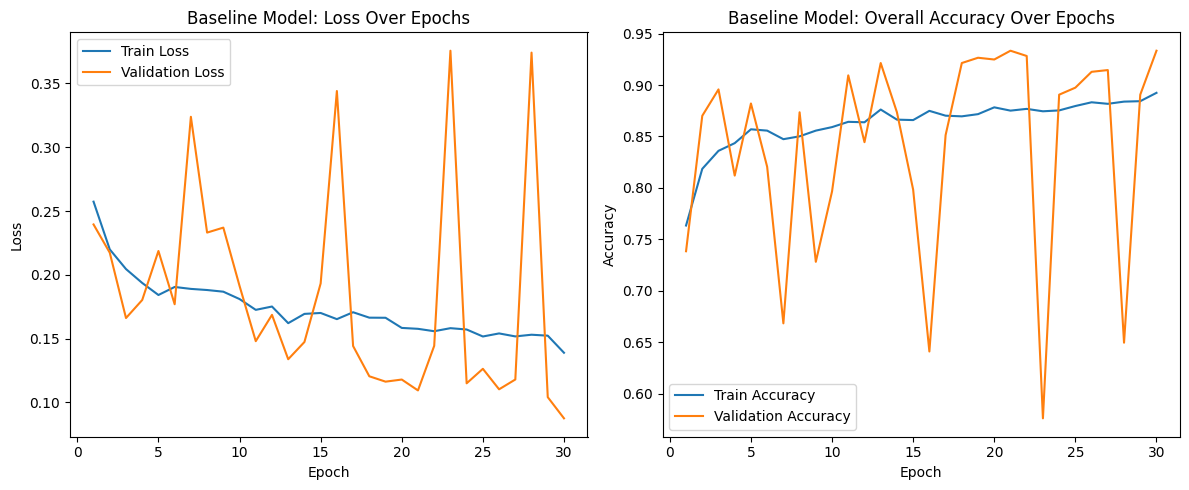

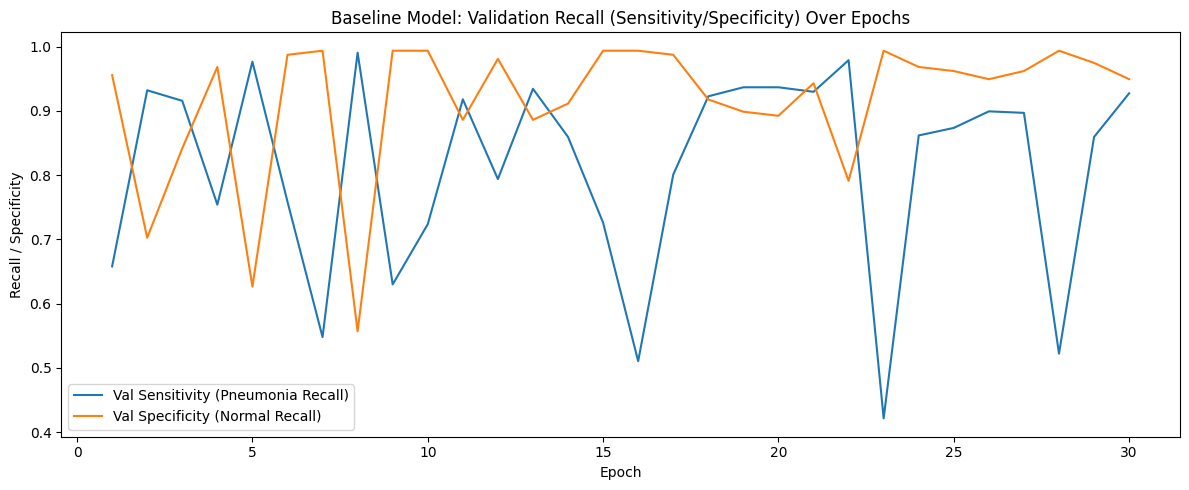

Model saved as 'chest_xray_model.pth'


In [34]:
# Initialize the model
model = SimpleModel().to(device)

# Define loss function and optimizer
        ########################################################################
        #                              YOUR CODE HERE                          #
        ########################################################################
pos_weight_tensor = torch.tensor([POS_WEIGHT_VAL], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=lr)

        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

# Train the model
train_losses, train_accuracies, val_losses, val_accuracies, train_class_accuracies, val_class_accuracies, best_model_state = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, device, use_wandb
)

# You can now save the best_model_state
# torch.save(best_model_state, 'filename.pth')

# Plot training curves
plot_training_curves(train_losses, train_accuracies, val_losses, val_accuracies, train_class_accuracies, val_class_accuracies)

# Save the model
torch.save(model.state_dict(), 'chest_xray_model.pth')
print("Model saved as 'chest_xray_model.pth'")

Evaluating Test Set:   0%|          | 0/19 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Evaluating Test Set: 100%|██████████| 19/19 [00:09<00:00,  2.02it/s]


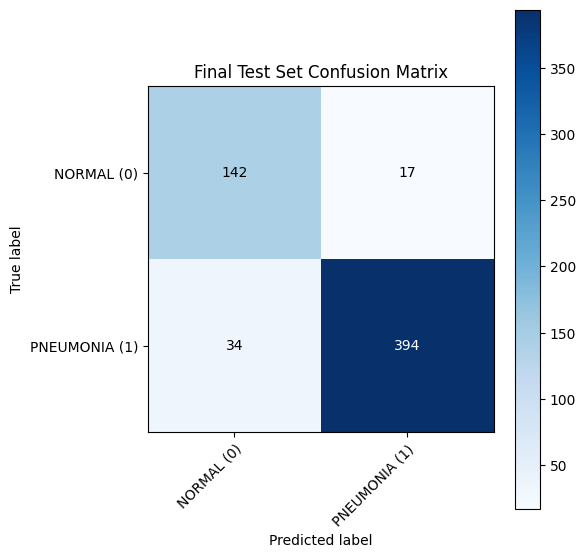

Test Loss                           : 0.1403
Overall Test Accuracy               : 0.9131
Class-Specific Accuracies:
Pneumonia Recall (Sensitivity)      : 0.9206
Normal Recall (Specificity)         : 0.8931
Pneumonia Precision (PPV)           : 0.9586


In [35]:
#Calling simple model
model_baseline = SimpleModel().to(device)

# Loading baseline weights
baseline_model_path = 'chest_xray_model.pth'
# Loading state dictionary
model_baseline.load_state_dict(torch.load(baseline_model_path, map_location=device))

pos_weight_tensor = torch.tensor([POS_WEIGHT_VAL], dtype=torch.float32).to(device)
final_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
#loading evaluate test function from final question (Q5)
baseline_test_metrics = evaluate_test_set(model_baseline, test_loader, final_criterion, device)

print(f"{'Test Loss':<35} : {baseline_test_metrics['Loss']:.4f}")
print(f"{'Overall Test Accuracy':<35} : {baseline_test_metrics['Accuracy']:.4f}")
print("Class-Specific Accuracies:")
print(f"{'Pneumonia Recall (Sensitivity)':<35} : {baseline_test_metrics['Sensitivity (Pneumonia Recall)']:.4f}")
print(f"{'Normal Recall (Specificity)':<35} : {baseline_test_metrics['Specificity (Normal Recall)']:.4f}")
print(f"{'Pneumonia Precision (PPV)':<35} : {baseline_test_metrics['Precision (Pneumonia)']:.4f}")

In [33]:
import os
print(os.listdir())

['.config', 'chest_xray_imp2_ablation_model.pth', 'chest_xray_final_model.pth', 'chest_xray_dataset_new_split', 'chest_xray_dataset', 'wandb', 'sample_data']


**(a) Design Choices**

Convolutional Neural Networks have been shown to exhibit strong performance on this task. As noted above, convolutional layers are effective for image data because they (i) process small, local regions of the image at a time, which allows detection of local features e.g. edges or corners and (ii) they use shared filter weights, applying the same filter across the entire image, which reduces the total number of parameters needed, making makes the model more efficient and less prone to overfitting. [1][2][3][4]

A strong baseline should be simple and shallow, stable to train, easily convergent, and well-aligned with biases present in the data set. This is achieved through the following design choices.

- I use a shallow model with three convolutional blocks (each with: Conv2d --> BatchNorm2d --> ReLU --> MaxPool2d(2)) for the baseline. The Max Pooling layers follow the convolutional layers to reduce the width and height of the feature map, allowing deeper layers to consider a much larger area of the original input and extract "high-level" features (linking together the local features captured by the shallow layers to capture the global structures, which are needed to make the classification decision). I also include Batch Normalisation in every block, as it is known to accelerate training and the stabilise optimisation process. Dropout is used to mitigate early overfitting of the training set, to support better generalisation on the validation set. The filter depth increases conservatively (16, 32, 64) to support computational efficiency.
- Binary Cross Entropy (BCE) loss is common in this task and allows mitigation of imbalance through class weighting.[2] Within this, I choose BCEWithLogitsLoss because it combines the sigmoid activation and the BCE, which has been shown to increase stability compared to using separate functions. As a result, first I calculate and integrate the pos_weight (ratio of NORMAL to PNEUMONIA examples) to increase penalisation of the minority NORMAL class to ensure the model prioritises high specificity, rather than favouring maximising recall on the majority class (sensitivity).
- Adam optimiser is chosen as a robust and efficient optimiser, and a moderate fixed learning rate (0.001) is chosen for simplicity (LR adjustment will be explored later on).
- The model is trained for a balance between allowing convergence and fast training times.

*[1] Sangeetha KP et al. (2025), Pneumonia Detection using Chest X-Ray Images: A Convolutional Neural Network with Skip Connection Approach*

*[2] Hasan MdR, Ullah SMA, Karim MdE. An Effective Framework for Identifying Pneumonia in Healthcare Using a Convolutional Neural Network. In: Proceedings of the 2023 International Conference on Electrical, Computer and Communication Engineering (ECCE). pp. 1-6. doi: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=10101548*

*[3] Aich S, Kim HC, Chakraborty S, et al. Detection of Pneumonia from Chest X-Rays using a Convolutional Neural Network Architecture. Available online: http://www.dbpia.co.kr/journal/articleDetail?nodeId=NODE08747418 (accessed on 23
January 2025).*

*[4] Wu H, Xie P, Zhang H, et al. Predict pneumonia with chest X-ray images based on convolutional deep neural learning networks. Journal of Intelligent & Fuzzy Systems. 2020; 39(3): 2893-2907. doi: 10.3233/jifs-191438*

**(b) Presentation of Results**


_Table 1. Baseline model performance on training, validation, and test sets._

| Metric                          | Training Set | Validation Set | Test Set |
|---------------------------------|--------------|----------------|----------|
| Accuracy                        | 0.8924       | 0.93333        | 0.9131   |
| Loss                            | 0.13897      | 0.08757.       | 0.1403   |
| Normal Recall (Specificity)     | 0.91153      | 0.94937        | 0.8931   |
| Pneumonia Recall (Sensitivity)  | 0.88531      | 0.9274         | 0.9206   |


_Figure 1. Loss and accuracy curves against epoch for baseline model training._
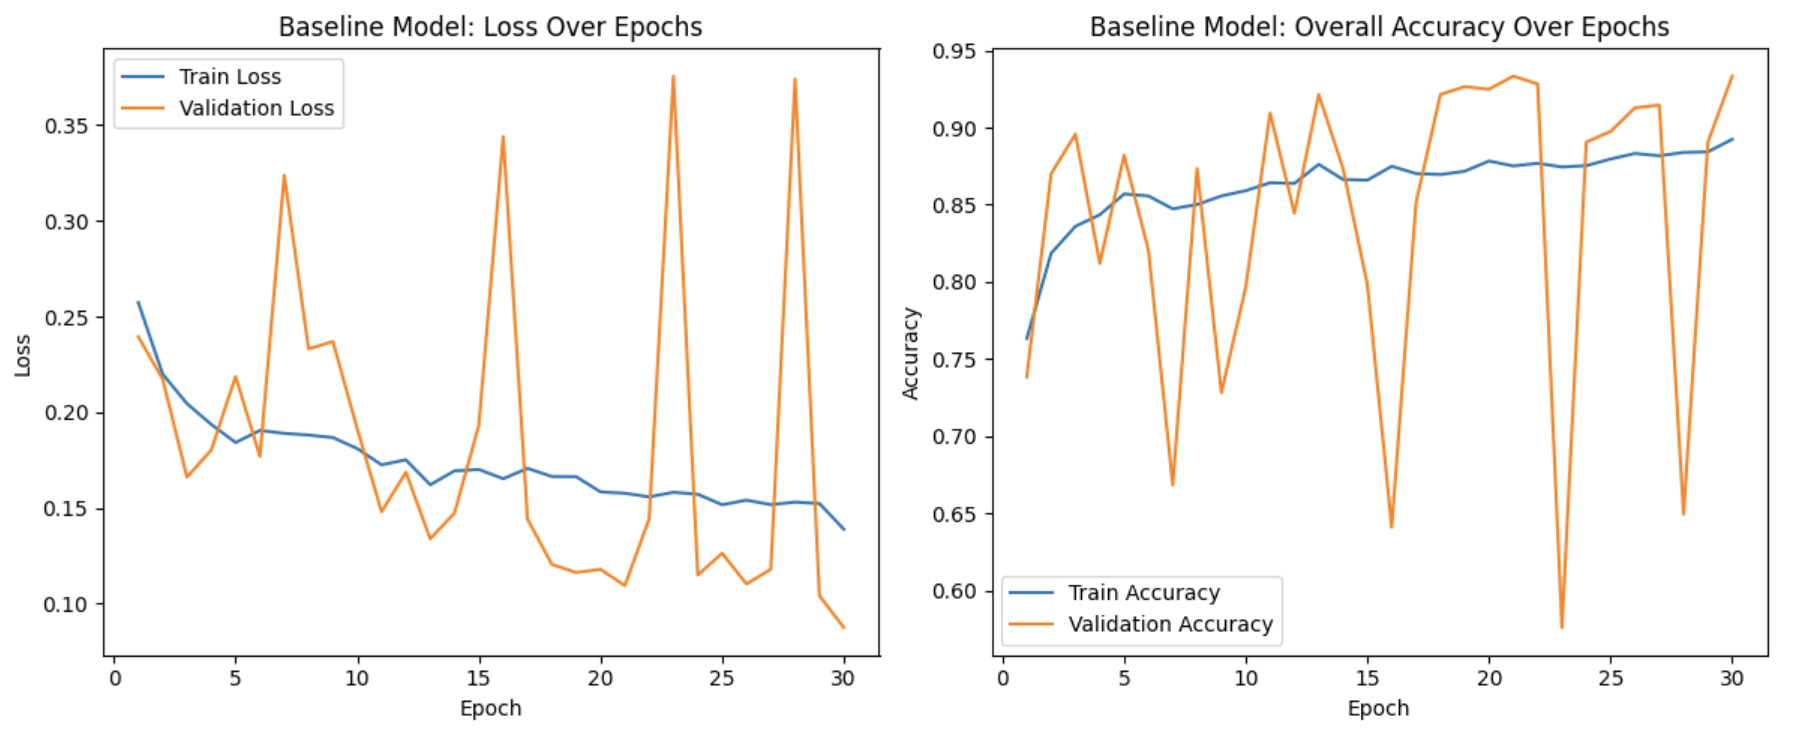



_Figure 2. Specificity and Sensitivity plotted against epoch._
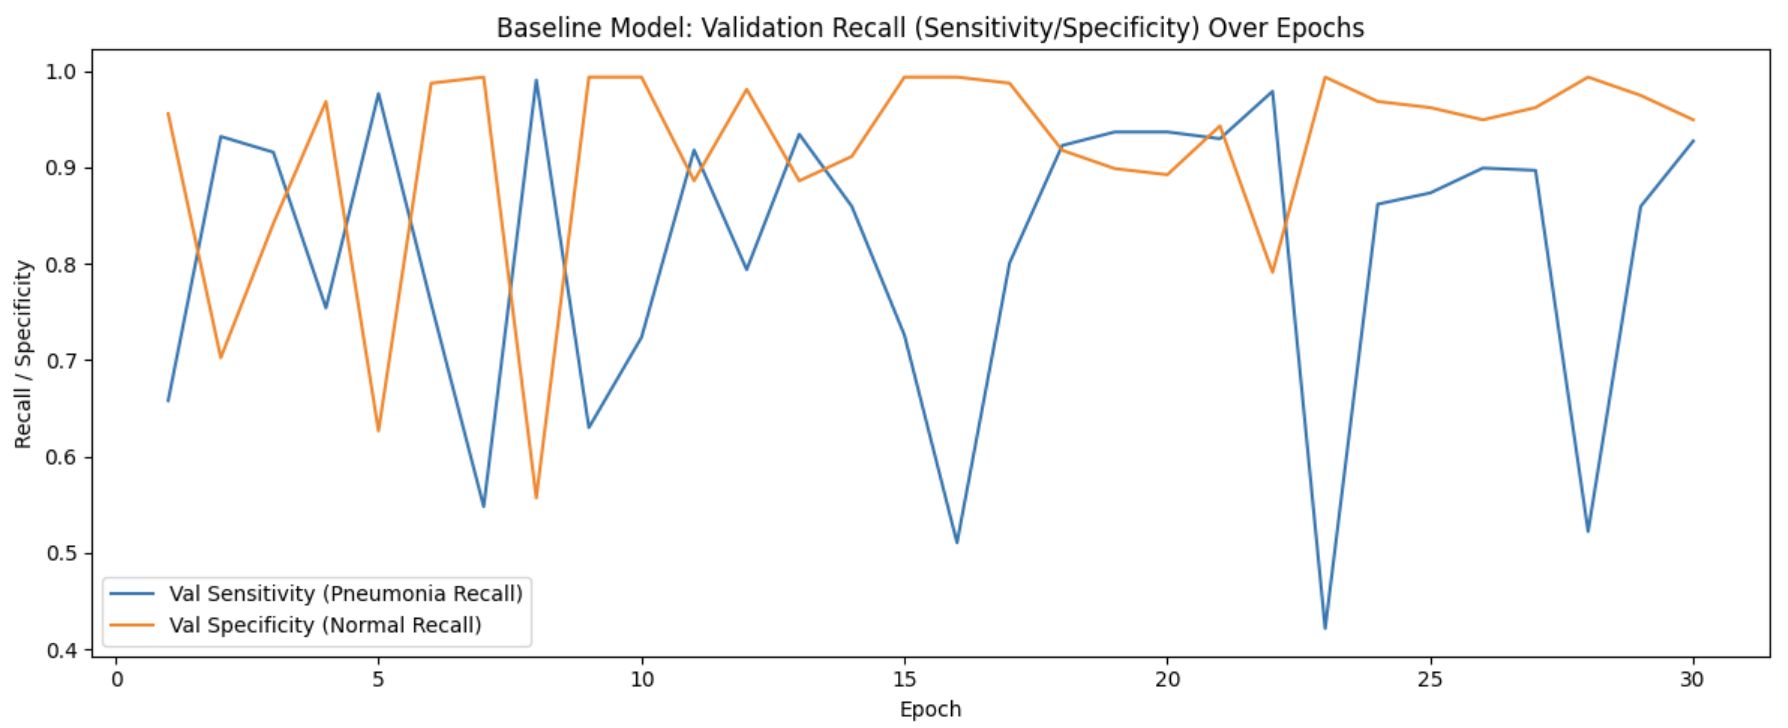

_Figure 3. Test set confusion matrix for baseline model._
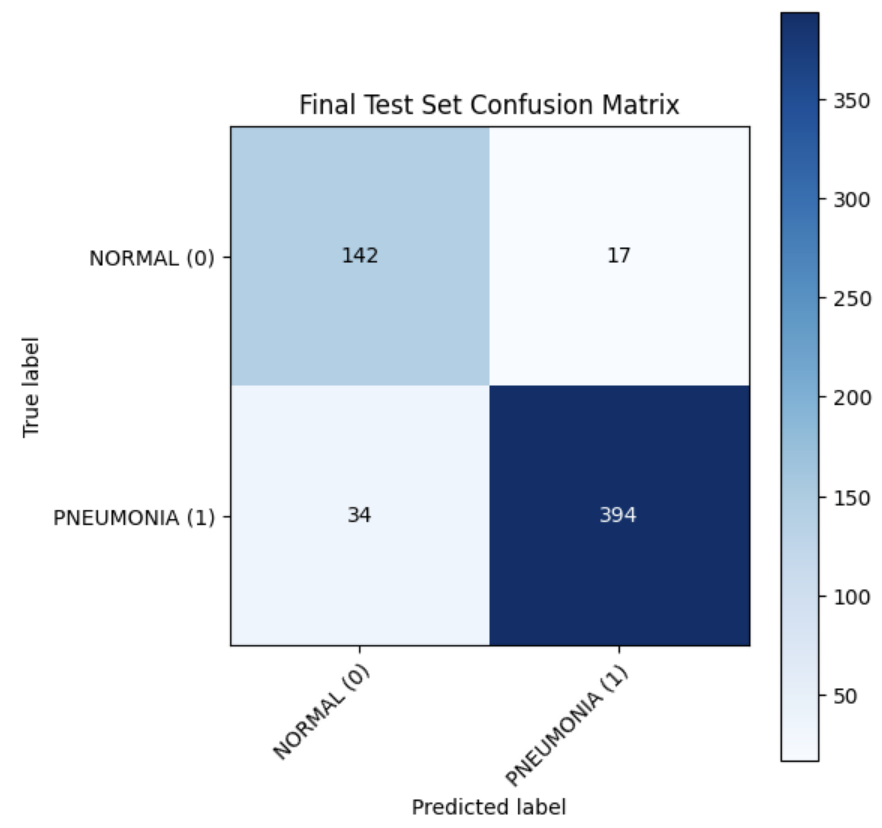

**(c) Discussion of Results**

The initial model shows strong accuracy on the training (89.22%) and validation (90.60%), as well as good generalisation to the test set (91.31%). The weighted loss apears to have successfully managed the class imbalance, with the recall of the minority NORMAL class on the test set strong at 89.31% (Table 1). Figure 4 shows that, when the model is trained on the test set, only 17 of 159 NORMAL samples are misclassified, and only 34 of 428 PNEUMONIA samples are misclassified.

However, it is clear from Figures 1 and 2 that the model suffers from high levels of instability, with accuracy crashing and loss spiking on numerous occasions and the model struggling to converge over 30 epochs. From Figure 2, this appears to be driven by in collapse in PNEUMONIA recall, with the model prioritising correct classification of the minority NORMAL class. This makes the model unreliable, with accuracy strongly depending on at which epoch training finishes.

These large swings and trade-offs between sensitivity and specificity suggest that the simple CNN architecture may lack the necessary depth to effectively extract the features needed to consistently distinguish NORMAL and PNEUMONIA cases. Further, the high instability indicates a poor optimisation approach: the fixed learning rate for the Adam optimiser may be too aggressive for the baseline architecture, causing the model to overshoot and oscillate in the minima. To mitigate this oscillation and make the trainingn more stable, it seems sensible to control the learning rate decay - cosine annealing may be a good option, and will be tested in the next section (Improvement 2). For better feature  discrimination, it also seems sensible to test a deeper model e.g. by integrating residual connections (Improvement 1).

Further, it is noted that the  dataset used here (Kermany et al., 2018 [1]) comprises chest X-ray images of one to five year olds from one location, the Guangzhou Women and Children's Medical Centre, Guangzhou.[2][3] However, among other things, the mean noise, contrast, and brightness can vary between X-ray machines.[4]

An effective X-ray classification system should be robust to such variations, and should not overfit to artefacts specific to the X-ray image processing rather than identifying the medical characteristics associated with pneumonia.

However, comparing the results on training and test sets is not useful for detection of this type of overfitting because the X-ray images in both come from the same source so are likely to have undergone the same original image processing etc. Instead, in Q4.4, photometric augmentation is applied (ColorJitter to modify brightness and contrast) in pre-processing to simulate such variations and the baseline model trained; the significantly poorer performance demonstrates the presence of overfitting and thus poor transferability. This same augmentation technique, alongside the other two improvements, is therefore used in the final model to improve its robustness (Improvement 3).

[1] Kermany, D.S. et al. (2018) Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning. Cell, 172(5), pp. 1122–1131.e9. doi: 10.1016/j.cell.2018.02.010
[2] Guo, K., Cheng, J., Li, K., Wang, L., Lv, Y. and Cao, D. (2023) 'Diagnosis and detection of pneumonia using weak-label based on X-ray images: a multi-center study', BMC Medical Imaging, 23(1), p. 209. doi: 10.1186/s12880-023-01174-4.
[3] Mooney, P.T. (2018) Chest X-Ray Images (Pneumonia) [Dataset], Kaggle. Available at: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia (Accessed: 7 December 2025).
[4] Tompe, A. and Sargar, K. (2022) X-Ray Image Quality Assurance. In: StatPearls. Treasure Island (FL): StatPearls Publishing.  Available at: https://www.ncbi.nlm.nih.gov/books/NBK564362/ (Accessed: 15 December 2025).

# Question 4: Improving the Baseline (50 marks)
After analysing the results of your baseline, can you spot any clear areas for improvement, or think of any obvious improvements to your model and training setup that will improve performance?

You are free to try out as many improvements as you want here. You may also try modifying aspects of the data.

**However, for the final code and results you present in your submission, you should use exactly 3 design choices which (attempt to) improve upon the baseline.**

Tips:
* If you struggle to improve upon the baseline, but your design choices are well motivated and well implemented, and your results are well-presented and discussed, you will still receive most marks here. You will get some extra marks for improving upon baseline performance, but you will primarily be marked for making reasonable design choices.
* A small number of marks will be deducted if there are extremely obvious issues with the baseline that you do not attempt to address

## Q 4.1: Final improved model -- baseline + 3 improvements (20 marks)



You should now choose three final improvements. Explain them, implement them, train a model, and present and discuss the results.

Try to maximize performance with the final three improvements you choose (i.e., pick the three best improvements you found).

In [25]:
# Implement the improvements and train the model in as many cells as you need.

########################################################################
#                              YOUR CODE HERE                          #
########################################################################

# Implement the experiment in as many cells as you need.

########################################################################
#                              YOUR CODE HERE                          #
########################################################################

# Integrating Mini RestNet blocks

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        # 1st Convolutional Layer in the block
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # 2nd Convolutional Layer in the block
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection (1x1 conv if dimensions change)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += self.shortcut(identity) # Add identity shortcut
        out = self.relu(out)
        return out

class ResNetModel(nn.Module):
    def __init__(self, num_classes=1):
        super(ResNetModel, self).__init__()

        # Initial layer: 224x224 -> 112x112
        self.in_channels = 16
        self.conv_in = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # ResNet Layers: (ResidualBlock, output_channels, num_blocks, stride)
        self.layer1 = self._make_layer(ResidualBlock, 16, 2, stride=1) # No downsampling
        self.layer2 = self._make_layer(ResidualBlock, 32, 2, stride=2) # Downsample x2
        self.layer3 = self._make_layer(ResidualBlock, 64, 2, stride=2) # Downsample x2

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride_val in strides:
            layers.append(block(self.in_channels, out_channels, stride_val))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv_in(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [26]:
def train_model_scheduler_only(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20, device='cuda', use_wandb=True):
    """Trains the model while stepping the learning rate scheduler after each epoch."""

    wandb.init(project="COMP0188_CW1_Justification",
               name="Q4.4_Baseline_w_Scheduler",
               config={
                   "model": "SimpleModel_CosineLR",
                   "num_epochs": num_epochs,
                   "initial_lr": optimizer.param_groups[0]['lr'],
                   "scheduler": "CosineAnnealingLR"
               })
    wandb.watch(model, criterion, log="all", log_freq=10)

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    train_class_accuracies = {'Pneumonia_Recall': [], 'Normal_Recall': []}
    val_class_accuracies = {'Pneumonia_Recall': [], 'Normal_Recall': []}

    best_val_accuracy = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        tp, tn, fp, fn = 0, 0, 0, 0
        total_samples = 0

        # Training loop
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)"):
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Same metric calculation
            preds = torch.round(torch.sigmoid(outputs))
            labels_int = labels.int()
            preds_int = preds.int()

            tp += ((preds_int == 1) & (labels_int == 1)).sum().item()
            tn += ((preds_int == 0) & (labels_int == 0)).sum().item()
            fp += ((preds_int == 1) & (labels_int == 0)).sum().item()
            fn += ((preds_int == 0) & (labels_int == 1)).sum().item()

            total_samples += labels.size(0)


        # Scheduler step after each epoch completes
        scheduler.step()
        # Log current learning rate
        wandb.log({"Train/Learning_Rate": optimizer.param_groups[0]['lr']}, step=epoch)

        # Calculate epoch metrics
        epoch_loss = running_loss / total_samples
        epoch_accuracy = (tp + tn) / total_samples if total_samples > 0 else 0.0

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        train_class_accuracies['Pneumonia_Recall'].append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        train_class_accuracies['Normal_Recall'].append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)


        # Validation loop (same as Q3)
        model.eval()
        val_loss = 0.0
        val_tp, val_tn, val_fp, val_fn = 0, 0, 0, 0
        val_total_samples = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Val)"):
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)

                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                preds = torch.round(torch.sigmoid(outputs))
                labels_int = labels.int()
                preds_int = preds.int()

                val_tp += ((preds_int == 1) & (labels_int == 1)).sum().item()
                val_tn += ((preds_int == 0) & (labels_int == 0)).sum().item()
                val_fp += ((preds_int == 1) & (labels_int == 0)).sum().item()
                val_fn += ((preds_int == 0) & (labels_int == 1)).sum().item()

                val_total_samples += labels.size(0)

        epoch_val_loss = val_loss / val_total_samples
        epoch_val_accuracy = (val_tp + val_tn) / val_total_samples if val_total_samples > 0 else 0.0
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)
        val_pneumonia_recall = val_tp / (val_tp + val_fn) if (val_tp + val_fn) > 0 else 0.0
        val_normal_recall = val_tn / (val_tn + val_fp) if (val_tn + val_fp) > 0 else 0.0
        val_class_accuracies['Pneumonia_Recall'].append(val_pneumonia_recall)
        val_class_accuracies['Normal_Recall'].append(val_normal_recall)

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

        # logging to wandb
        wandb.log({
            "Train/Loss": epoch_loss,
            "Val/Loss": epoch_val_loss,
            "Val/Accuracy": epoch_val_accuracy,
            "Val/Pneumonia_Recall": val_pneumonia_recall,
            "Val/Normal_Recall": val_normal_recall
        })

        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy
            best_model_state = model.state_dict()

    wandb.finish()

    return train_losses, train_accuracies, val_losses, val_accuracies, train_class_accuracies, val_class_accuracies, best_model_state


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224
batch_size = 32 # Use the same batch size as previous runs
POS_WEIGHT_VAL = 0.3704

train_transform_final = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),

    # Photometric augmentation: randomly adjust brightness and contrast (to improve generalisation)
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # Keeping baseline geometric augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
])

train_dataset_final = ChestXrayDataset(root_dir=dataset_path, split='train', transform=train_transform_final)
train_loader_final = DataLoader(train_dataset_final, batch_size=batch_size, shuffle=True, num_workers=4)

Epoch 1/30 (Val): 100%|██████████| 19/19 [00:08<00:00,  2.37it/s]


Epoch 1/30: Train Loss: 0.1908, Train Acc: 0.8467, Val Loss: 2.5591, Val Acc: 0.2838, LR: 0.000997


Epoch 2/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.03it/s]


Epoch 2/30: Train Loss: 0.1475, Train Acc: 0.8864, Val Loss: 0.1362, Val Acc: 0.9282, LR: 0.000989


Epoch 3/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.02it/s]


...

Epoch 29/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.02it/s]


Epoch 29/30: Train Loss: 0.0604, Train Acc: 0.9564, Val Loss: 0.0840, Val Acc: 0.9453, LR: 0.000003


Epoch 30/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.03it/s]

Epoch 30/30: Train Loss: 0.0608, Train Acc: 0.9556, Val Loss: 0.0835, Val Acc: 0.9453, LR: 0.000000


Train/Learning_Rate,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
Train/Loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▃▂▂▂▁▂▂▁▁▁▁▁▁
Val/Accuracy,▁█▇█▆▇██▃▃▆██▇█▆██▇███████████
Val/Loss,█▁▁▁▁▁▁▁▃▃▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
Val/Normal_Recall,█▆▇▇▇▇▆▇██▇▇▆████▅▁▅▇▇▇▇▇▆██▇█
Val/Pneumonia_Recall,▁█▇█▆▇█▇▃▃▆██▇▇▆▇██████████▇██
Train/Learning_Rate,0
Train/Loss,0.06082
Val/Accuracy,0.9453
Val/Loss,0.08352
Val/Normal_Recall,0.96203


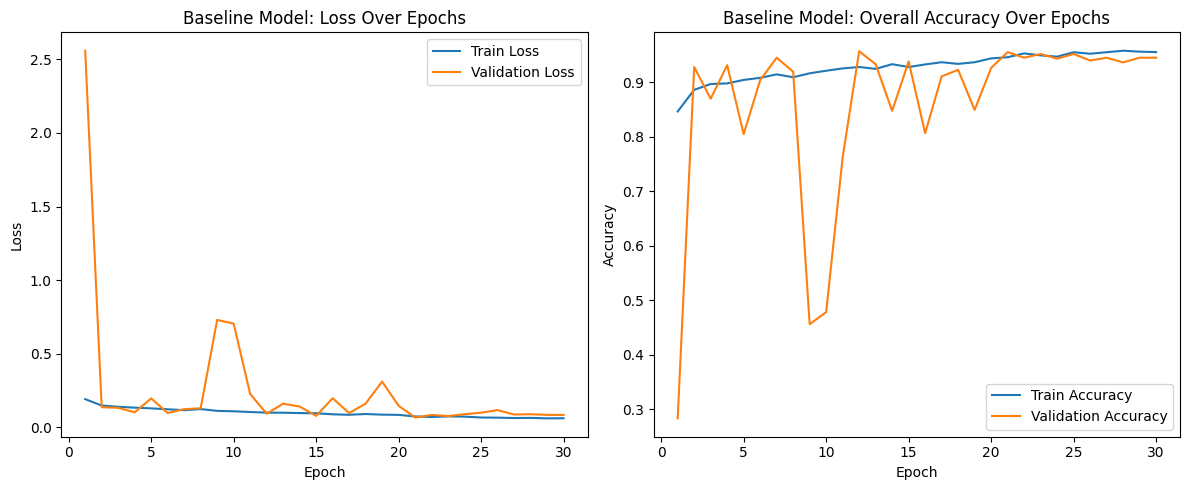

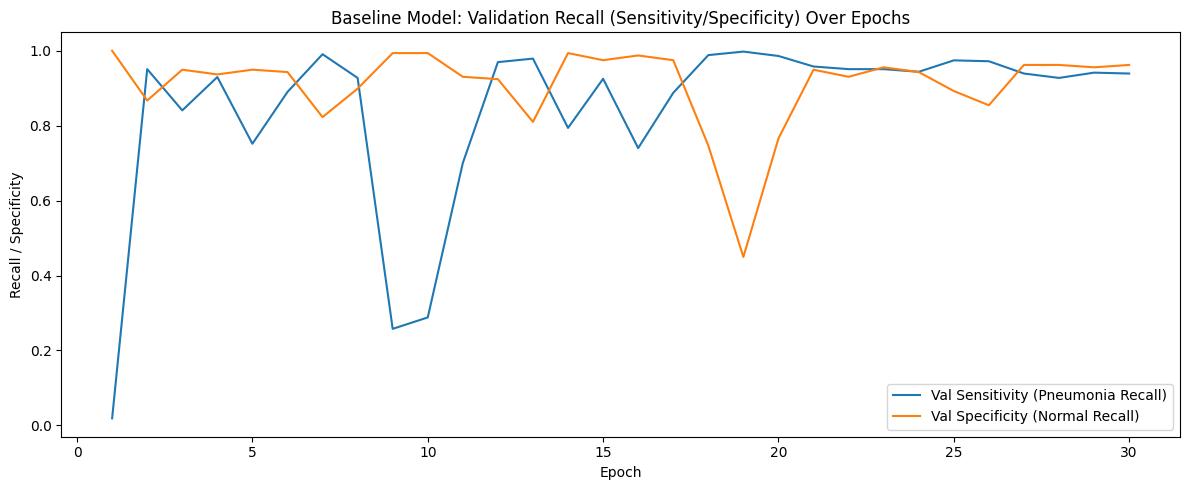

In [28]:
import wandb
from tqdm import tqdm

# Initialise ResNet model (improvement 1)
model_final = ResNetModel().to(device)

# Defining weighted BCELogitsLoss and Adam optimiser
pos_weight_tensor = torch.tensor([POS_WEIGHT_VAL], dtype=torch.float32).to(device)
criterion_final = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_final = optim.Adam(model_final.parameters(), lr=1e-3)

# Defining cosine annealing scheduler (Improvement 2)
num_epochs_q41 = 30
scheduler_final = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_final, T_max=num_epochs_q41)

# 4. Initialize WandB
wandb.init(project="COMP0188_CW1_Final",
           name="Q4.1_Final_ResNet_All_Improvements",
           config={"model": "ResNet_FullSystem_CosineLR",
                   "improvements": "ResNet + Jitter + CosineLR"})

train_results_final = train_model_scheduler_only(
    model_final,
    train_loader_final,  # Includes colorjitter
    val_loader,          # Standard val loader
    criterion_final,
    optimizer_final,
    scheduler_final,
    num_epochs=num_epochs_q41,
    device=device,
    use_wandb=True
)

plot_training_curves(
    train_results_final[0], train_results_final[1],
    train_results_final[2], train_results_final[3],
    train_results_final[4], train_results_final[5]
)

# Save the BEST model state (returned as the 7th element) for the Test Set evaluation (Q5)
best_model_state_final = train_results_final[-1]
torch.save(best_model_state_final, 'chest_xray_final_model.pth')

**(a) Explanation of Improvements**

The final three improvements were selected to address limitations in performance of the shallow model, and issues with both optimisation stability and generalisation capacity.

**_Improvement 1: Increasing Model Depth (Maximising Feature Extraction and Performance)_**

The baseline model is incorrectly classifying approximately 11% of NORMAL cases and 8% of PNEUMONIA cases. The shallow baseline model is not likely to be deep enough to effectively extract high-level features e.g. full object detection and specific pathologies (e.g. consolidation - air in alveolis being replaced by fluid)). As such, deeper architectures are explored; to mitigate common vanishing gradient and degradation issues, skip connections are considered (shown to be useful in this task by Sangeetha KP et al. (2025)[1]).

I choose to build a from-scratch Residual Neural Network (ResNet) Architecture (not pre-trained!) :
- Input Stage, which performs initial feature extraction and spatial downsampling via a convolutional layer and max pooling, reducing the image size to $112 \times 112$ pixels while setting the channel depth to 16.
- Three feature extraction stages (Layer 1, Layer 2, Layer 3), each composed of two Residual Blocks (Layer 1 maintains the spatial size and channel depth; Layer 2 and Layer 3 perform aggressive downsampling (stride=2) in their initial blocks, progressively reducing the feature map size while increasing the channel depth from 16 to 32 and finally to 64)
- The classification head then uses adaptive average pooling to flatten the 28 x 28 x 64 feature map, which is fed through a dropout layer and then a final linear layer to output the final binary prediction

**_Improvement 2: Cosine Annealing (Addressing Instability)_**

A Cosine Annealing Learning Rate Scheduler (CosineAnnealingLR) is employed to address the high instability (empirical evidence: Figures 1 and 2 from Q3) observed in validation of the baseline model.[2] It appears that the constant high learning rate results in the optimiser oscillating or jumping out of loss minima. The scheduler modulates the Adam optimizer's learning rate, lowering the it smoothly towards zero to allow the optimiser to effectively settle in more generalisable loss minimum.

**_Improvement 3: Photometric Augmentation (Addressing Overfitting)_**

The model is likely overfitting to the specific visual properties of the dataset. This is demonstrated dramatically in Q4.4, where the baseline model is trained on a training set with jittering applied, and then validated on the original validation set (without jittering). Here training accuracy is 86.19% and validation accuracy is 29.57%, largely driven by a fall in PNEUMONIA recall from 86.66% on the training set to 3.513% on the validation set. This is strong evidence that the baseline model overfits to image features rather than medical features.

transforms.ColorJitter is introduced to force the model to classify images despite variations in contrast or brightness, which should cause it to better learn features that are invariant to noise. While this is expected to decrease performance of the model on this specific dataset, the idea is to create a model that can be more reliably applied to X-ray images outside of the Kermany dataset (better transferability).

[1] Sangeetha KP et al. (2025), Pneumonia Detection using Chest X-Ray Images: A Convolutional Neural Network with Skip Connection Approach
[2] Bilogur, A. (2021) LR Schedulers, Adaptive Optimizers, PyTorch Training Performance Guide. Available at: https://residentmario.github.io/pytorch-training-performance-guide/lr-sched-and-optim.html [Accessed 11 December 2025].


**(b) Results:**

_Table 2. Test Set Performance Comparison of Baseline and Final Models._

| Metric                               | Baseline | Final Model |
|-------------------------------------|----------|-------------|
| Test Loss                           | 0.1403   | 0.1168      |
| Overall Test Accuracy               | 0.9131   | 0.9267      |
| Pneumonia Recall (Sensitivity)      | 0.9206   | 0.9369      |
| Normal Recall (Specificity)         | 0.8931   | 0.8994      |

_Figure 4. Comparing Loss (left) and Accuracy (right) stability of Baseline (a) and Final (b) Models._
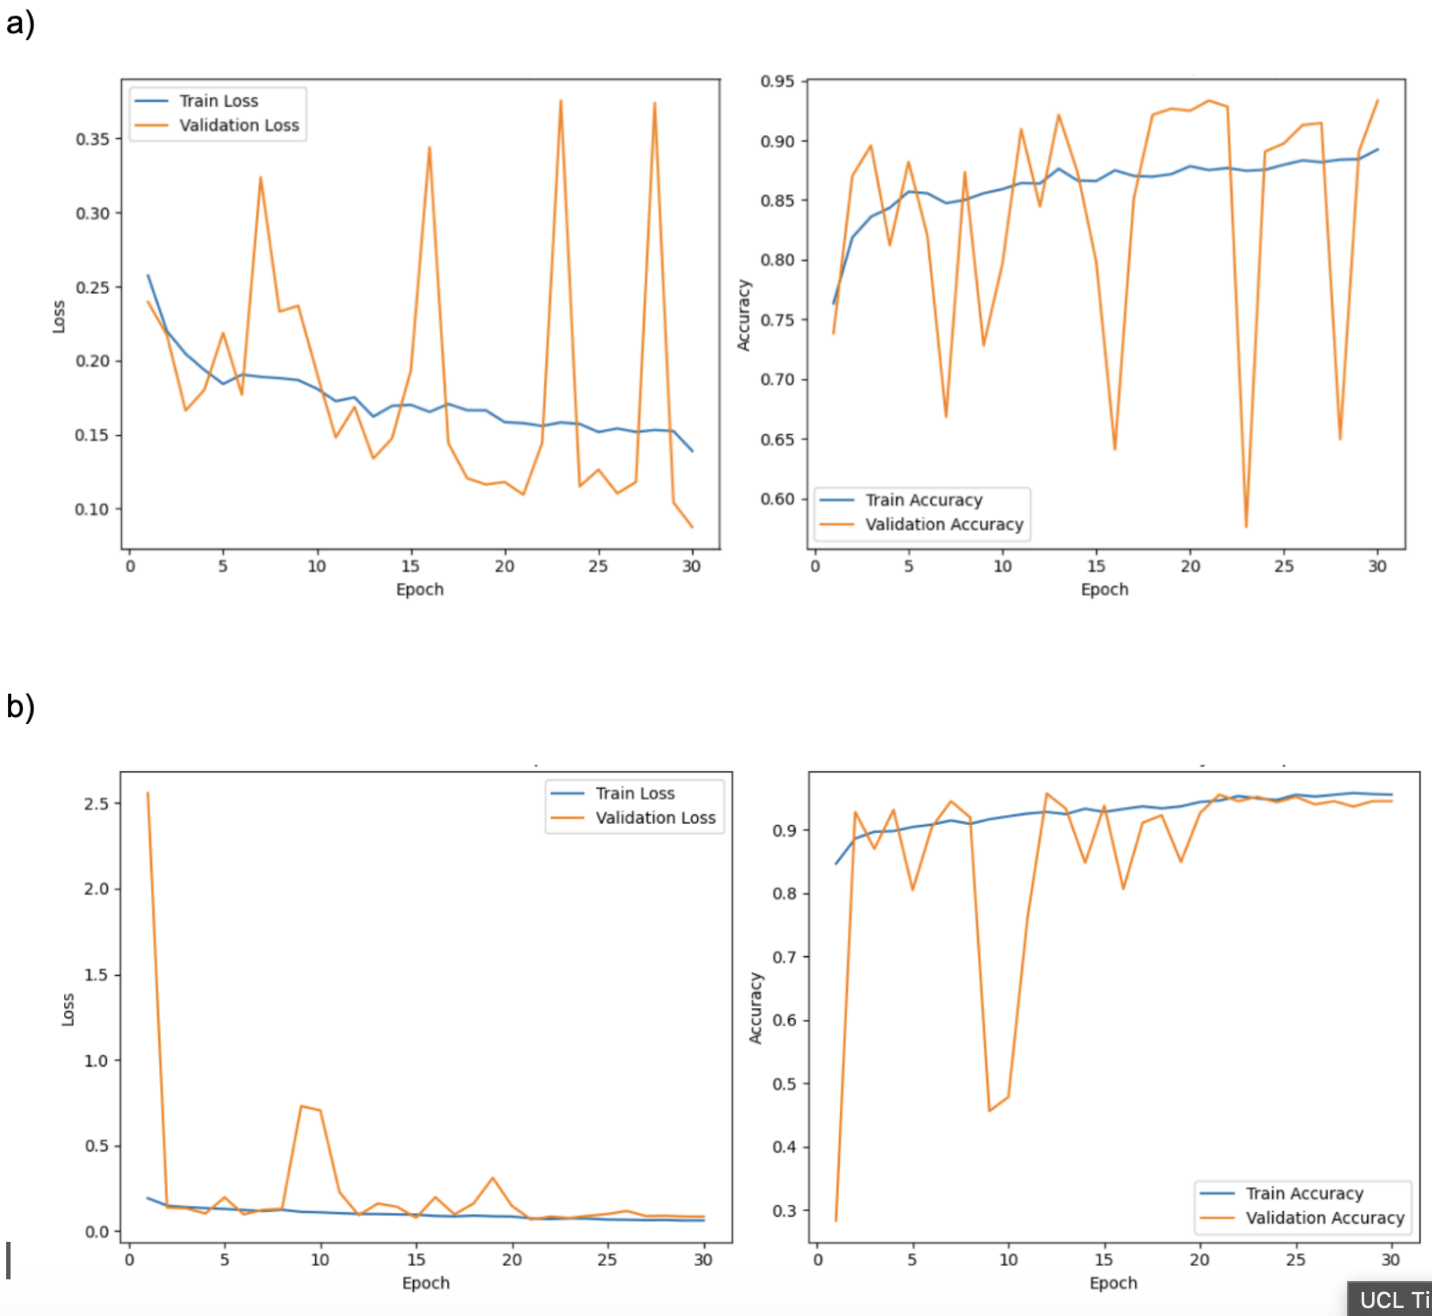



_Figure 5. Comparing Specificity and Sensitivity stability of Baseline (a) and Final (b) Models._

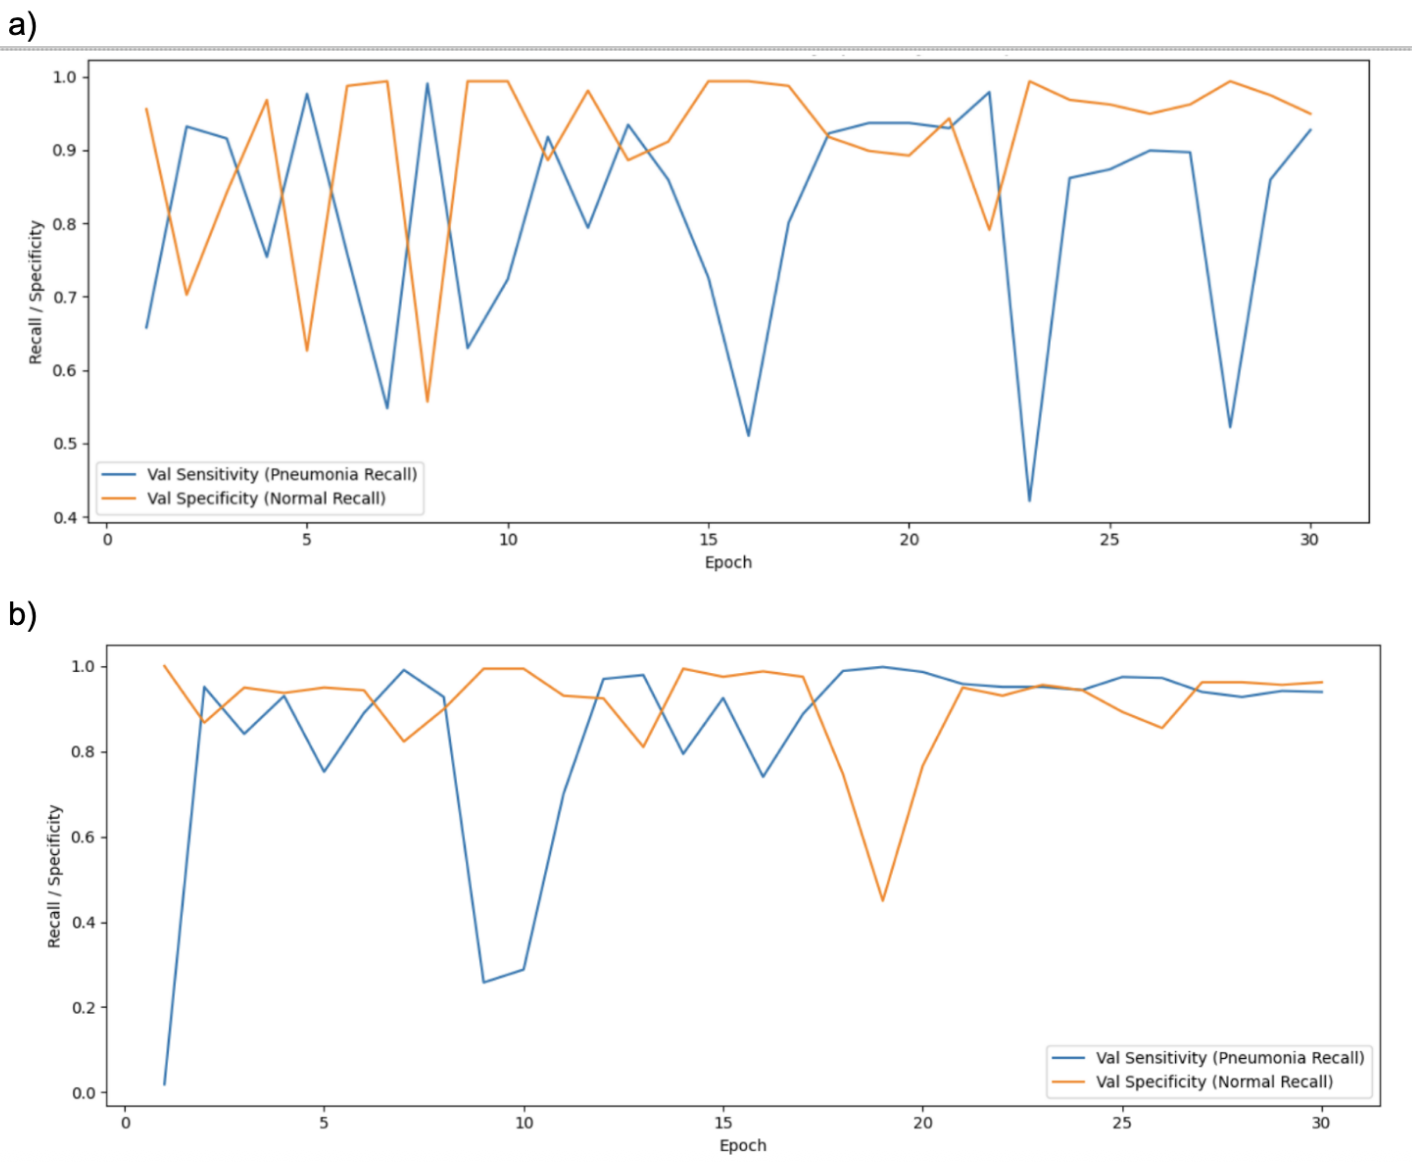

_Figure 6. Comparing confusion matrices for Baseline (a) and Final (b) models._

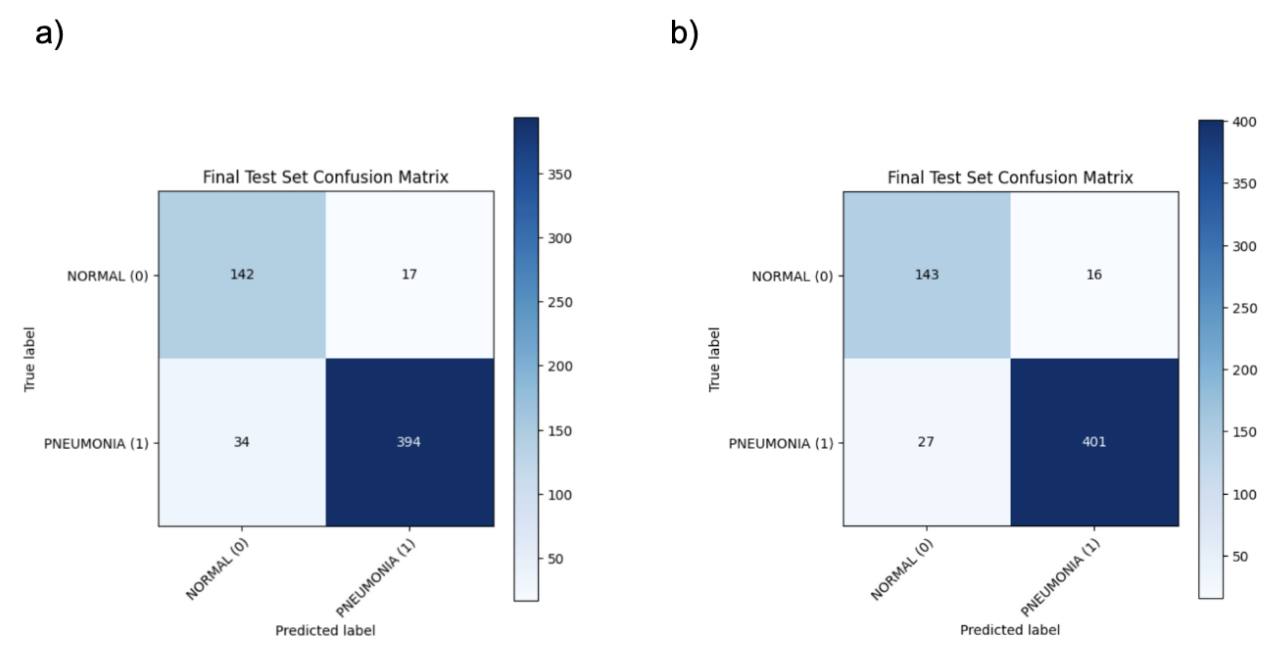

**(c) Discussion:**

As shown in Table 2, despite being forced to work harder to generalise due to photometric augmentation, the Final Model outperforms the baseline across all metrics, causing a decrease of 2.35% in the loss, and increases of 1.36%, 1.63%, and 0.64% in Overall Test Accuracy, Sensitivity, and Specificity respectively. Figure 6 plots the confusion matrices for both models, with the final model reducing the number of misclassified PNEUMONIA samples from 34 to 27 and the number of misclassified NORMAL samples from 17 to 16.

The contribution of the deeper ResNet architecture and cosine annealing to model robustness (to variations in contrast or brightness) and transferability can be quantified by observing the difference in maximum validation accuracy values for this Final Model (Validation Accuracy = 95.56%) and for the baseline when photometric augmentation is applied (Q4.4, Validation Accuracy = 88.72%). This gap of 6.84% highlights the enhanced capacity of the improved model to handle differences processed images, suggesting that it is much more effective in elucidating medical features of pneumonia, rather than overfitting to features/ artefacts of this specific type of X-ray image.

Most striking, however, is the major improvement in model stability. The introduction of cosine annealing-based learning rate scheduling enables convergence at around Epoch 21 (Figures 4 and 5), with a balance between PNEUMONIA and NORMAL recall achieved, and stabilisation of both loss and accuracy. By contrast, convergence is not achieved in 30 epochs for the baseline model, which exhibits great instability throughout.

## Q 4.2: Empirically justify improvement 1 (10 marks)

## Improvement 1: Residual Network Architecture (Option 2)

Now you will empirically demonstrate the contribution of each improvement to the final performance of your model.

To justify the utility of an improvement, you should present one of the following experiments:
- *Option 1:* Train the final model _without_ that improvement (but still with the other two improvements). Compare these results to the results you presented previously with all three improvements. If the improvement is useful, removing it should result in a drop in performance
- *Option 2:* Compare the performance of baseline to the perfroamnce of the baseline plus a single improvement. If the improvement is useful, you should expect improved performance versus the baseline.

You will still get a significant portion of the marks if the proposed improvement was well-motivated but does not empirically improve perfromance. In this case, ensure your discussion touches on why performance may not have improved or any other interesting talking points.


In [19]:
# Implement the experiment in as many cells as you need.

########################################################################
#                              YOUR CODE HERE                          #
########################################################################

# Integrating Mini RestNet blocks

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        # 1st Convolutional Layer in the block
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # 2nd Convolutional Layer in the block
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection (1x1 conv if dimensions change)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += self.shortcut(identity) # Add identity shortcut
        out = self.relu(out)
        return out

class ResNetModel(nn.Module):
    def __init__(self, num_classes=1):
        super(ResNetModel, self).__init__()

        # Initial layer: 224x224 -> 112x112
        self.in_channels = 16
        self.conv_in = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # ResNet Layers: (ResidualBlock, output_channels, num_blocks, stride)
        self.layer1 = self._make_layer(ResidualBlock, 16, 2, stride=1) # No downsampling
        self.layer2 = self._make_layer(ResidualBlock, 32, 2, stride=2) # Downsample x2
        self.layer3 = self._make_layer(ResidualBlock, 64, 2, stride=2) # Downsample x2

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride_val in strides:
            layers.append(block(self.in_channels, out_channels, stride_val))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv_in(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

Epoch 1/30 (Val): 100%|██████████| 19/19 [00:08<00:00,  2.18it/s]


Epoch 1/30: Train Loss: 0.1765, Train Acc: 0.8580, Val Loss: 0.6312, Val Acc: 0.6393
  Train Recall (Pneumonia/Normal): 0.8467/0.8886
  Val Recall (Pneumonia/Normal): 0.5082/0.9937


Epoch 2/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.10it/s]


Epoch 2/30: Train Loss: 0.1367, Train Acc: 0.8939, Val Loss: 0.1069, Val Acc: 0.9350
  Train Recall (Pneumonia/Normal): 0.8888/0.9076
  Val Recall (Pneumonia/Normal): 0.9415/0.9177


Epoch 3/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.02it/s]


...

Epoch 29/30 (Val): 100%|██████████| 19/19 [00:08<00:00,  2.31it/s]


Epoch 29/30: Train Loss: 0.0626, Train Acc: 0.9571, Val Loss: 0.0612, Val Acc: 0.9556
  Train Recall (Pneumonia/Normal): 0.9573/0.9566
  Val Recall (Pneumonia/Normal): 0.9461/0.9810


Epoch 30/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.01it/s]

Epoch 30/30: Train Loss: 0.0589, Train Acc: 0.9567, Val Loss: 0.0536, Val Acc: 0.9744
  Train Recall (Pneumonia/Normal): 0.9558/0.9589
  Val Recall (Pneumonia/Normal): 0.9789/0.9620


Train/Accuracy,▁▃▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█▇███▇█▇███
Train/Loss,█▆▄▄▄▃▃▃▃▃▂▂▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁
Train/Normal_Recall,▁▃▅▅▅▆▅▅▆▆▆▆▆▇▆▇▇▇█▇▆██▇█▇▇█▇█
Train/Pneumonia_Recall,▁▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█▇█▇███▇█▇███
Val/Accuracy,▁▇█▇▇▆▆▇▇▇█▆█▇▅▇████▅█▇█▆▇█▇██
Val/Loss,█▂▁▁▂▂▂▁▁▃▁▂▂▁▂▂▂▁▁▁▂▁▁▁▃▂▁▂▁▁
Val/Normal_Recall,█▆▇█▇████▃██▆██▅▆▇█▇█▆█▇▁██▄█▇
Val/Pneumonia_Recall,▁▇█▇▇▆▆▇▇█▇▆█▇▅███▇█▅█▇██▇██▇█
Train/Accuracy,0.95666
Train/Loss,0.05892
Train/Normal_Recall,0.95893


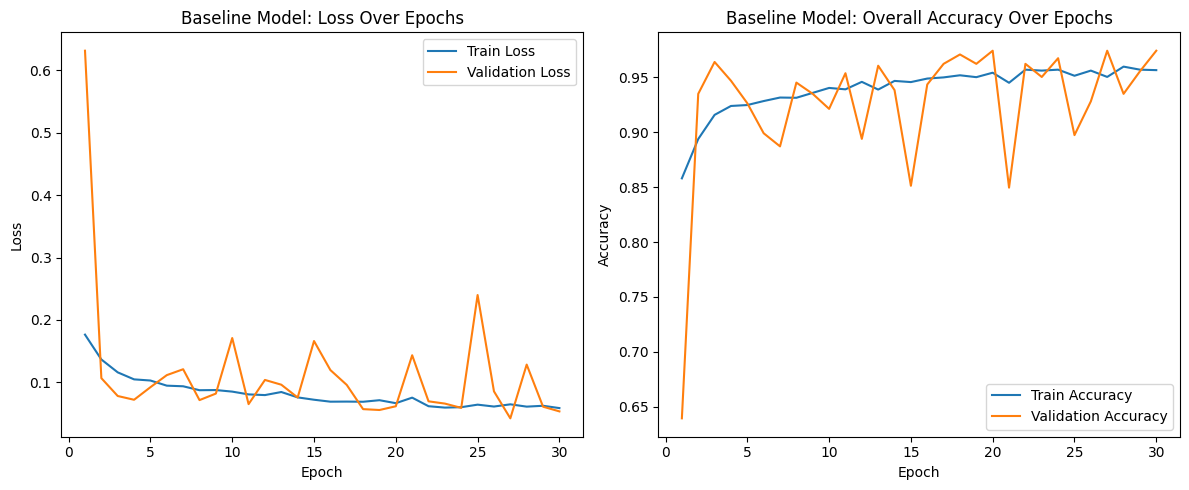

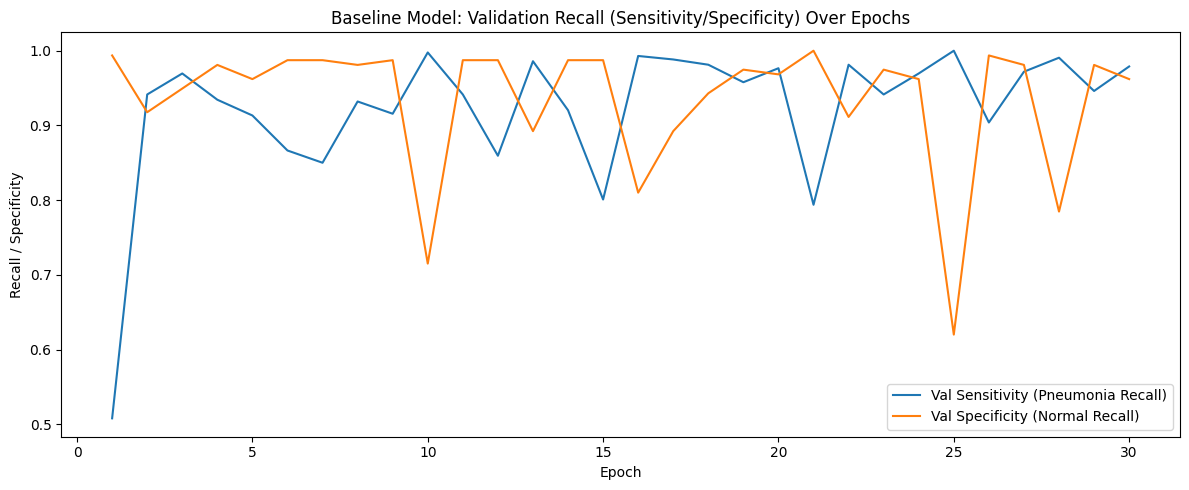

In [23]:
model_imp1 = ResNetModel().to(device)

# Defining loss and optimiser, same as before
pos_weight_tensor = torch.tensor([POS_WEIGHT_VAL], dtype=torch.float32).to(device)
criterion_imp1 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

optimizer_imp1 = optim.Adam(model_imp1.parameters(), lr=lr)

use_wandb_imp1 = True
if use_wandb_imp1:
    import wandb
    wandb.init(project="COMP0188_CW1_Justification",
               name="Q4.2_ResNetOnly_vs_Baseline",
               config={"model": "ResNet_FixedLR_SimpleAug"})

# Training using Q3 train_model function
num_epochs_imp1 = 30

train_results_imp1 = train_model(
    model_imp1,
    train_loader,      # Using baseline data loader - i.e. preprocessing same for fair comparison
    val_loader,
    criterion_imp1,
    optimizer_imp1,
    num_epochs=num_epochs_imp1,
    device=device,
    use_wandb=use_wandb_imp1
)

# Plotting results and saving best state
plot_training_curves(
    train_results_imp1[0], train_results_imp1[1],
    train_results_imp1[2], train_results_imp1[3],
    train_results_imp1[4], train_results_imp1[5]
)

torch.save(train_results_imp1[-1], 'chest_xray_imp1_only_model.pth')

**(a) Increasing Model Depth: ResNet Architecture - OPTION 2**
It is expected that the shallow sequential CNN architecture lacks sufficient depth to capture global features effectively, limiting its ability for effective classification. It is therefore replaced with a deeper architecture built using residual blocks (Mini-ResNet structure) with skip connections, as discussed above. Option 2, comparison of the baseline to the baseline plus this change of architecture (with no other changes), is used to evaluate the success of the improvement here, as it allows elucidation of whether the improvement works independently of cosine annealing and feature augmentation.

**(b)**

_Table 3. Comparison of Baseline model and Improvement 1 (ResNet architecture) performance on Validation Set._

| Metric                          | Improvement 1 | Baseline |
|---------------------------------|--------------|----------------|
| Accuracy                        | 0.97436      | 0.93333        |
| Loss                            | 0.05364      | 0.08757        |
| Normal Recall (Specificity)     | 0.96203      | 0.94937        |
| Pneumonia Recall (Sensitivity)  | 0.97892      | 0.9274         |


_Figure 7. Loss and accuracy plotted against number of epochs for Improvement 1._

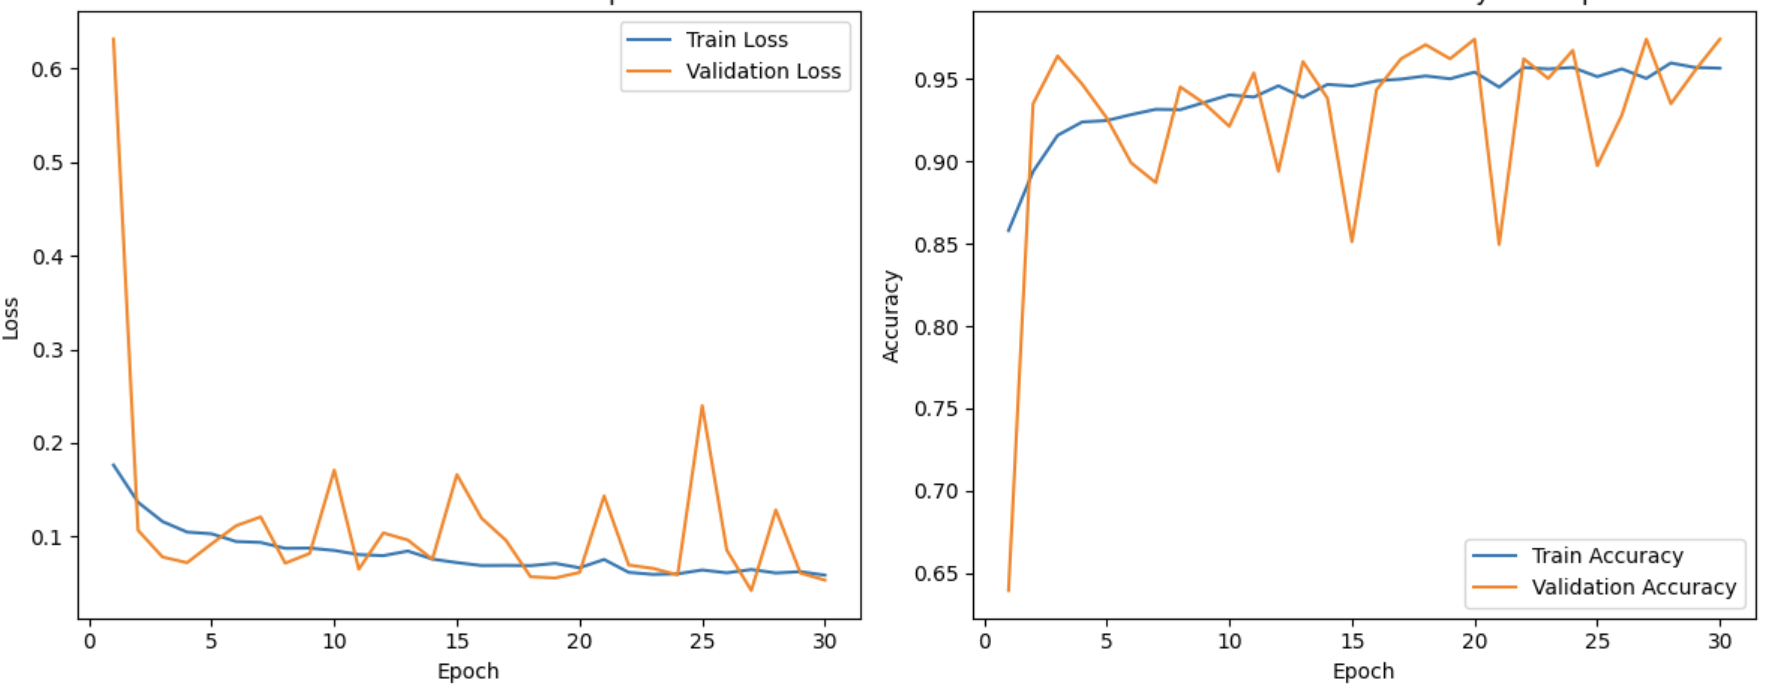



_Figure 8. Sensitivity and Specificity plotted against number of epochs for improvement 1._
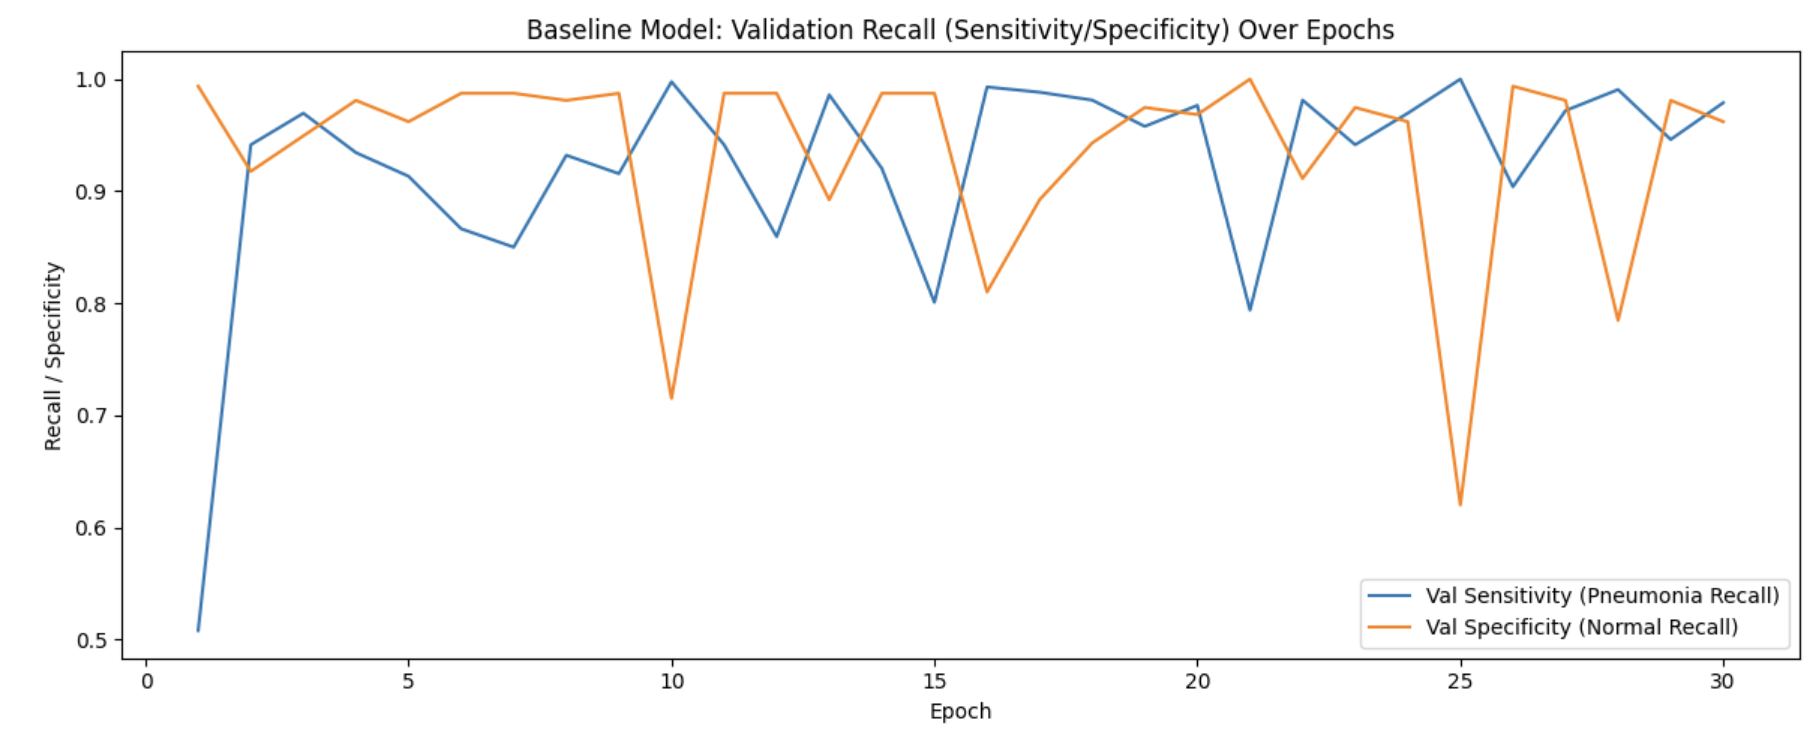

**(c)**

The gain in performance with introduction of the deeper ResNet-based architecture is dramatic, with validation accuracy increasing from 93.33% to 97.44% (Table 3). This suggests that the architectural change successfully addressed the insufficient feature extraction capacity of the shallow baseline The most significant gain was in Sensitivity (Pneumonia Recall, increase of 5.15%), which indicates that the deeper network, enabled by skip connections, improves the model's ability to extract the high-level clinical features that are needed to minimise false negatives.

However, the model fails to converge in 30 epochs, with none of validation loss, accuracy, sensitivity, or specificity stabilising (Figures 7 and 8). This reinforces the indication that the fixed learning rate is not allowing the optimiser to find a low minimum with good generalisability in the loss landscape. This adds weight to the argument that a learning rate scheduler is needed - cosine annealing will be applied and evaluated in Q4.3.

## Q 4.3: Empirically justify improvement 2 (10 marks)

## Improvement 2: Learning Rate Scheduling (Option 2)

Epoch 1/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.05it/s]


Epoch 1/30: Train Loss: 0.2561, Train Acc: 0.7630, Val Loss: 0.2210, Val Acc: 0.7778, LR: 0.000997


Epoch 2/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.05it/s]


Epoch 2/30: Train Loss: 0.2145, Train Acc: 0.8281, Val Loss: 0.1652, Val Acc: 0.8701, LR: 0.000989


Epoch 3/30 (Val): 100%|██████████| 19/19 [00:08<00:00,  2.35it/s]


...

Epoch 29/30 (Val): 100%|██████████| 19/19 [00:07<00:00,  2.40it/s]


Epoch 29/30: Train Loss: 0.1403, Train Acc: 0.9012, Val Loss: 0.0907, Val Acc: 0.9368, LR: 0.000003


Epoch 30/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.02it/s]

Epoch 30/30: Train Loss: 0.1416, Train Acc: 0.8939, Val Loss: 0.0893, Val Acc: 0.9368, LR: 0.000000


Train/Learning_Rate,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
Train/Loss,█▆▅▅▄▄▄▄▄▃▄▃▃▃▃▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁
Val/Accuracy,▄▆▅▇▇▅▇▇▆▃▁▇▇█▆▇▇█▇▇▇▇▆▇██████
Val/Loss,▄▃▄▃▄▄▂▃▃▅█▂▂▂▂▄▂▁▂▃▂▁▂▂▁▁▁▁▁▁
Val/Normal_Recall,█▇█▄▄█▆▅▇██▇▅▆█▁███▅█████▇█▇▇▇
Val/Pneumonia_Recall,▄▆▅▇▇▄▇▇▆▃▁▇█▇▅█▆▇▆▇▆▆▅▆▇▇▇▇▇▇
Train/Learning_Rate,0
Train/Loss,0.14157
Val/Accuracy,0.93675
Val/Loss,0.08926
Val/Normal_Recall,0.96203


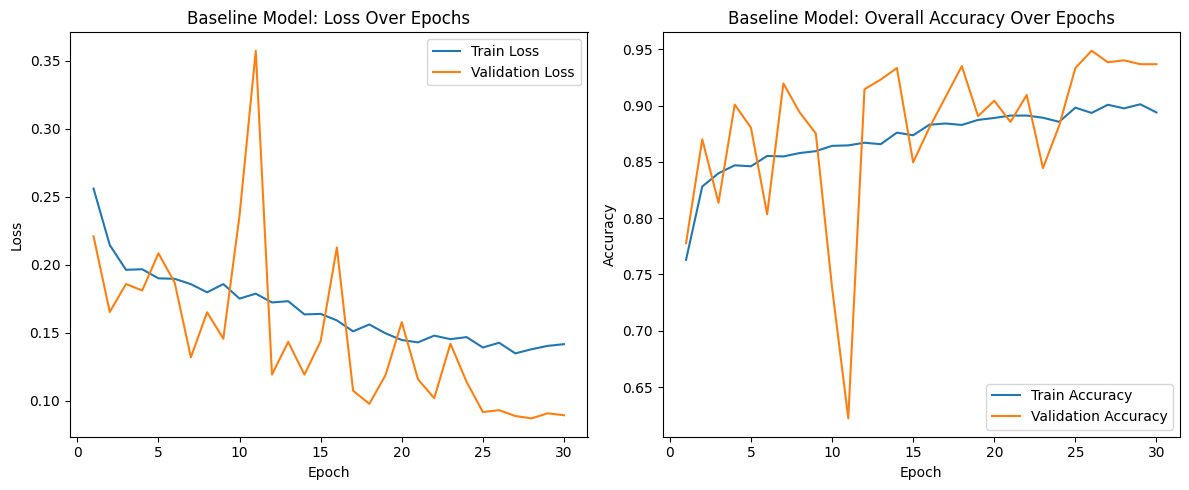

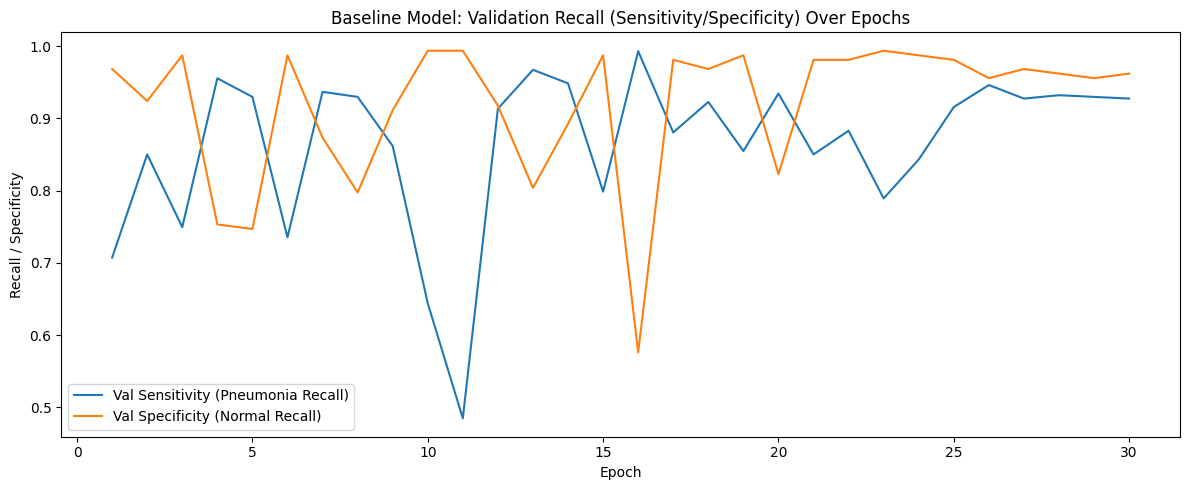

Model for Improvement 3 justification saved.


In [25]:
# Implement the experiment in as many cells as you need.

########################################################################
#                              YOUR CODE HERE                          #
########################################################################


def train_model_scheduler_only(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20, device='cuda', use_wandb=True):
    """Trains the model while stepping the learning rate scheduler after each epoch."""

    wandb.init(project="COMP0188_CW1_Justification",
               name="Q4.4_Baseline_w_Scheduler",
               config={
                   "model": "SimpleModel_CosineLR",
                   "num_epochs": num_epochs,
                   "initial_lr": optimizer.param_groups[0]['lr'],
                   "scheduler": "CosineAnnealingLR"
               })
    wandb.watch(model, criterion, log="all", log_freq=10)

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    train_class_accuracies = {'Pneumonia_Recall': [], 'Normal_Recall': []}
    val_class_accuracies = {'Pneumonia_Recall': [], 'Normal_Recall': []}

    best_val_accuracy = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        tp, tn, fp, fn = 0, 0, 0, 0
        total_samples = 0

        # Training loop
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)"):
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Same metric calculation
            preds = torch.round(torch.sigmoid(outputs))
            labels_int = labels.int()
            preds_int = preds.int()

            tp += ((preds_int == 1) & (labels_int == 1)).sum().item()
            tn += ((preds_int == 0) & (labels_int == 0)).sum().item()
            fp += ((preds_int == 1) & (labels_int == 0)).sum().item()
            fn += ((preds_int == 0) & (labels_int == 1)).sum().item()

            total_samples += labels.size(0)


        # Scheduler step after each epoch completes
        scheduler.step()
        # Log current learning rate
        wandb.log({"Train/Learning_Rate": optimizer.param_groups[0]['lr']}, step=epoch)

        # Calculate epoch metrics
        epoch_loss = running_loss / total_samples
        epoch_accuracy = (tp + tn) / total_samples if total_samples > 0 else 0.0

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        train_class_accuracies['Pneumonia_Recall'].append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        train_class_accuracies['Normal_Recall'].append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)


        # Validation loop (same as Q3)
        model.eval()
        val_loss = 0.0
        val_tp, val_tn, val_fp, val_fn = 0, 0, 0, 0
        val_total_samples = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Val)"):
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)

                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                preds = torch.round(torch.sigmoid(outputs))
                labels_int = labels.int()
                preds_int = preds.int()

                val_tp += ((preds_int == 1) & (labels_int == 1)).sum().item()
                val_tn += ((preds_int == 0) & (labels_int == 0)).sum().item()
                val_fp += ((preds_int == 1) & (labels_int == 0)).sum().item()
                val_fn += ((preds_int == 0) & (labels_int == 1)).sum().item()

                val_total_samples += labels.size(0)

        epoch_val_loss = val_loss / val_total_samples
        epoch_val_accuracy = (val_tp + val_tn) / val_total_samples if val_total_samples > 0 else 0.0
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)
        val_pneumonia_recall = val_tp / (val_tp + val_fn) if (val_tp + val_fn) > 0 else 0.0
        val_normal_recall = val_tn / (val_tn + val_fp) if (val_tn + val_fp) > 0 else 0.0
        val_class_accuracies['Pneumonia_Recall'].append(val_pneumonia_recall)
        val_class_accuracies['Normal_Recall'].append(val_normal_recall)

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

        # logging to wandb
        wandb.log({
            "Train/Loss": epoch_loss,
            "Val/Loss": epoch_val_loss,
            "Val/Accuracy": epoch_val_accuracy,
            "Val/Pneumonia_Recall": val_pneumonia_recall,
            "Val/Normal_Recall": val_normal_recall
        })

        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy
            best_model_state = model.state_dict()

    wandb.finish()

    return train_losses, train_accuracies, val_losses, val_accuracies, train_class_accuracies, val_class_accuracies, best_model_state

# Initialising baseline model i.e. without ResNet
model_imp3 = SimpleModel().to(device)

# Loss and optimisers
POS_WEIGHT_VAL = 0.3704 # Fixed from Q1 analysis
pos_weight_tensor = torch.tensor([POS_WEIGHT_VAL], dtype=torch.float32).to(device)
criterion_imp3 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_imp3 = optim.Adam(model_imp3.parameters(), lr=1e-3)

# Defining the Cosine Annealing Scheduler
num_epochs_q44 = 30
scheduler_imp3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_imp3, T_max=num_epochs_q44) # T_max = num_epochs

# Training the model
train_results_imp3 = train_model_scheduler_only(
    model_imp3,
    train_loader,# Baseline data loader
    val_loader,
    criterion_imp3,
    optimizer_imp3,
    scheduler_imp3, # Scheduler included
    num_epochs=num_epochs_q44,
    device=device,
    use_wandb=True
)

# Plotting for comparison to baseline
plot_training_curves(
    train_results_imp3[0], train_results_imp3[1],
    train_results_imp3[2], train_results_imp3[3],
    train_results_imp3[4], train_results_imp3[5]
)

# Saving
torch.save(train_results_imp3[-1], 'chest_xray_imp3_only_model.pth')
print("Model for Improvement 3 justification saved.")

**(a) Learning Rate Scheduling - OPTION 2**

The baseline model is highly unstable, as is the improved Mini-ResNet model. As noted, controlling the learning rate decay rather than using a fixed learning rate may result in greater stability. Cosine annealing is a common technique that uses a cosine curve to gradually increase the learning rate, which helps it to find better minima, improve convergence speed and stability, and also escape local optima by periodically boosting the learning rate.[1] Cosine annealing is tested here for this reason. Option 2 is again chosen to isolate any improvements that result from the cosine annealing: improvements seen in Option 1 may be instead a result of interaction between the scheduling and the other improvements.

[1] Bilogur, A. (2021) LR Schedulers, Adaptive Optimizers, PyTorch Training Performance Guide. Available at: https://residentmario.github.io/pytorch-training-performance-guide/lr-sched-and-optim.html [Accessed 11 December 2025].

**(b) Results:**

_Table 4. Comparison of Baseline model performance and Improvement 2 (Cosine Annealing) on the Validation Set._
| Metric                          | Improvement 1 | Baseline |
|---------------------------------|--------------|----------------|
| Accuracy                        | 0.93675      | 0.93333        |
| Loss                            | 0.08926      | 0.08757        |
| Normal Recall (Specificity)     | 0.96203      | 0.94937       |
| Pneumonia Recall (Sensitivity)  | 0.9274       | 0.9274        |



_Figure 9. Loss and accuracy plots against number of epochs for Improvement 2._

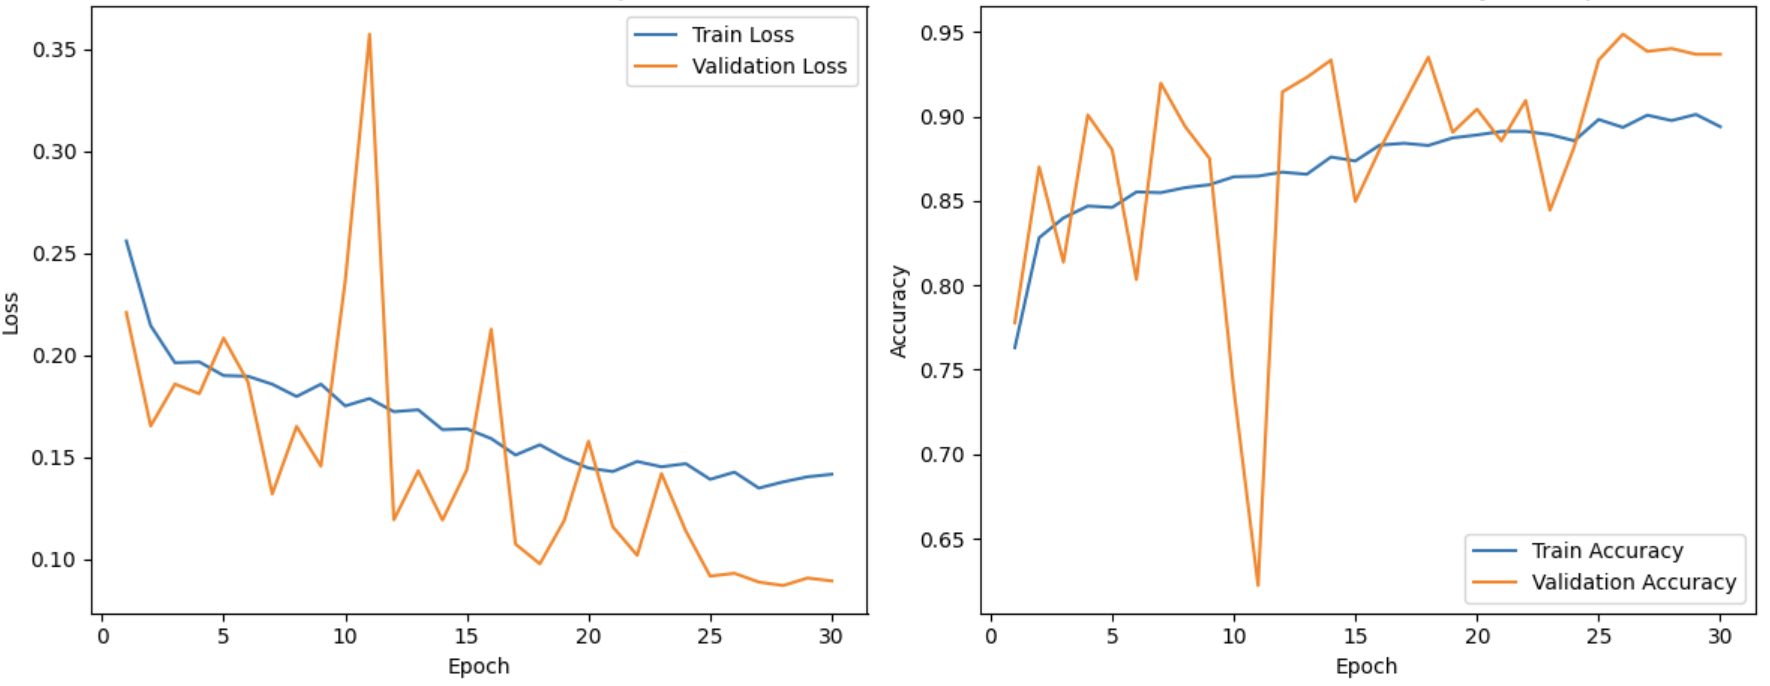

_Figure 10. Validation Sensitivity and Specificity plots against number of epochs._

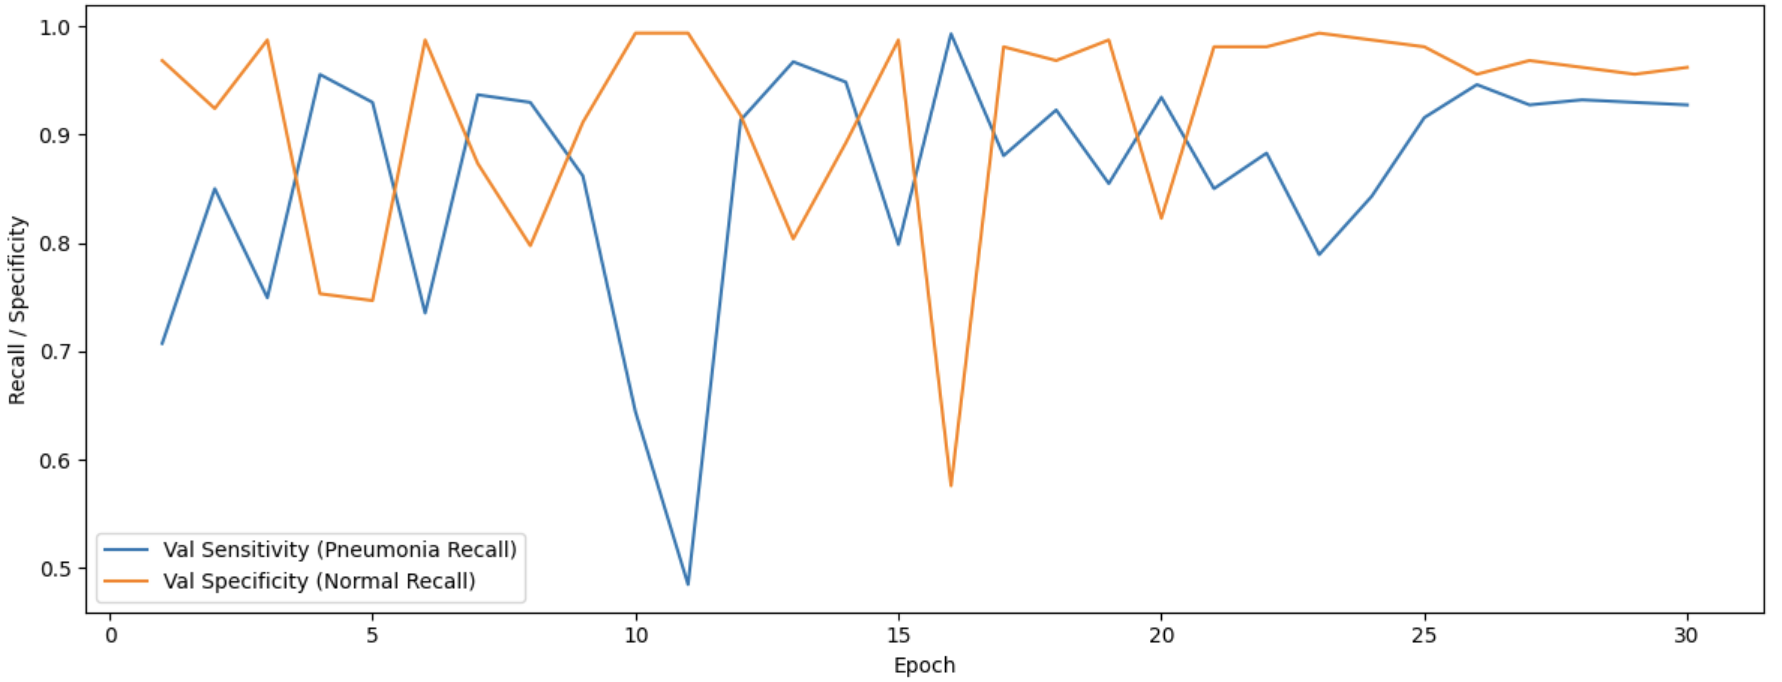

**(c) Discussion:**

Improvement 2 shows minor improvements in accuracy on the validation set (raising it by 0.34%), driven by an increase in performance on the minority NORMAL (Specificity) class of 1.27% (Table 4). Sensitivity remains the same as the baseline.

However, the main goal of the learning rate scheduling was not to improve accuracy on one given epoch but to promote stability and convergence during validation. Improvement 2, the implementation of a cosine annealing learning rate scheduler, is highly successful in this regard: Figures 9 and 10 demonstrate that convergence occurs at Epoch 26 here, with the validation set loss, accuracy, specificity, and sensitivity all stabilising. This stabilisation is not observed in the baseline - nor in the ResNet modification - indicating that cosine annealing is responsible for this and is working as intended.

Further, this control of rate decay appears to allow the model to more effectively balance specificity and sensitivity. There are dramatic swings, particularly in sensitivity, in the baseline (Figure 5), which continue all the way to epoch 30; this is largely eliminated after epoch 20 here.

Overall, cosine annealing has significantly stabilised performance on the validation set to produce a much more reliable model. It is therefore an effective addition.

## Q 4.4: Empirically justify improvement 3 (10 marks)

## Further data augmentation
##Option 2: Implementing augmentation only on baseline

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: harryfyjiswalker (harryfyjiswalker-ucl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

Epoch 29/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.07it/s]


Epoch 29/30: Train Loss: 0.1631, Train Acc: 0.8775, Val Loss: 1.4862, Val Acc: 0.3624
  Train Recall (Pneumonia/Normal): 0.8739/0.8870
  Val Recall (Pneumonia/Normal): 0.1265/1.0000


Epoch 30/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.04it/s]

Epoch 30/30: Train Loss: 0.1721, Train Acc: 0.8691, Val Loss: 2.0191, Val Acc: 0.2957
  Train Recall (Pneumonia/Normal): 0.8660/0.8776
  Val Recall (Pneumonia/Normal): 0.0351/1.0000


Train/Accuracy,▁▄▅▅▆▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇▇▇▇█████
Train/Loss,█▅▄▄▄▄▄▃▃▃▃▃▃▂▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▂
Train/Normal_Recall,▁▃▄▄▄▄▅▃▄▄▆▇▆▇▆▆▄▇▆▆█▆▇▆▆▇▆▇▇▆
Train/Pneumonia_Recall,▁▄▅▅▆▆▆▇▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇█████
Val/Accuracy,▇▇▅▁▅█▃▇▄▃█▇▃█▃▆▅▁▅▄▃▁▃▇▂▂▇▁▂▁
Val/Loss,▁▁▂▃▂▁▃▁▂▃▁▁▂▁▃▂▂▇▂▂▄▇▂▁▆▃▁▄▆█
Val/Normal_Recall,█▇███▇█▇██▂▇█▅█▇███████▇██▁███
Val/Pneumonia_Recall,▆▇▄▁▅▇▃▆▄▃█▆▃█▃▅▅▁▅▄▃▁▃▇▂▂█▁▂▁
Train/Accuracy,0.86913
Train/Loss,0.17209
Train/Normal_Recall,0.87757


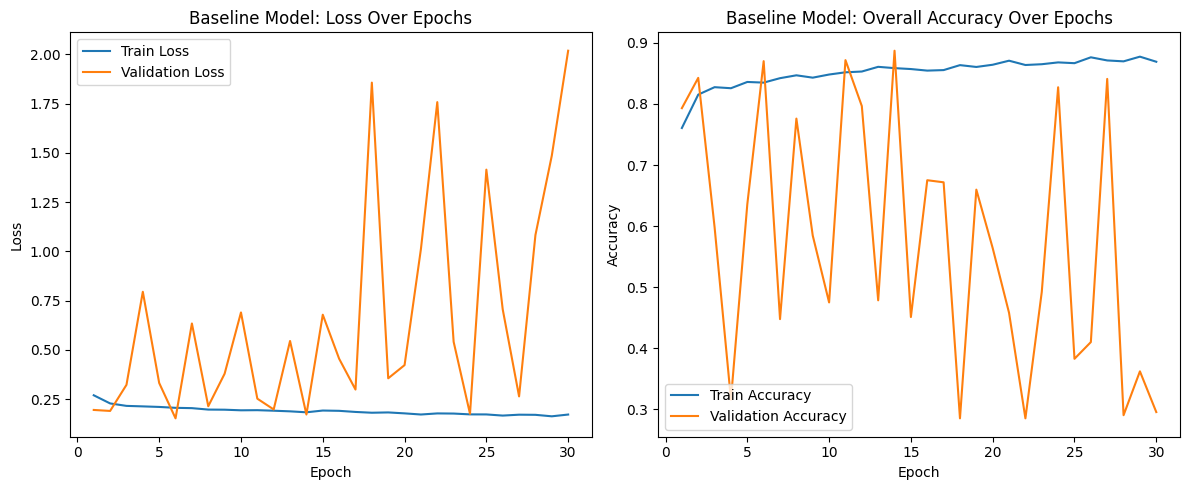

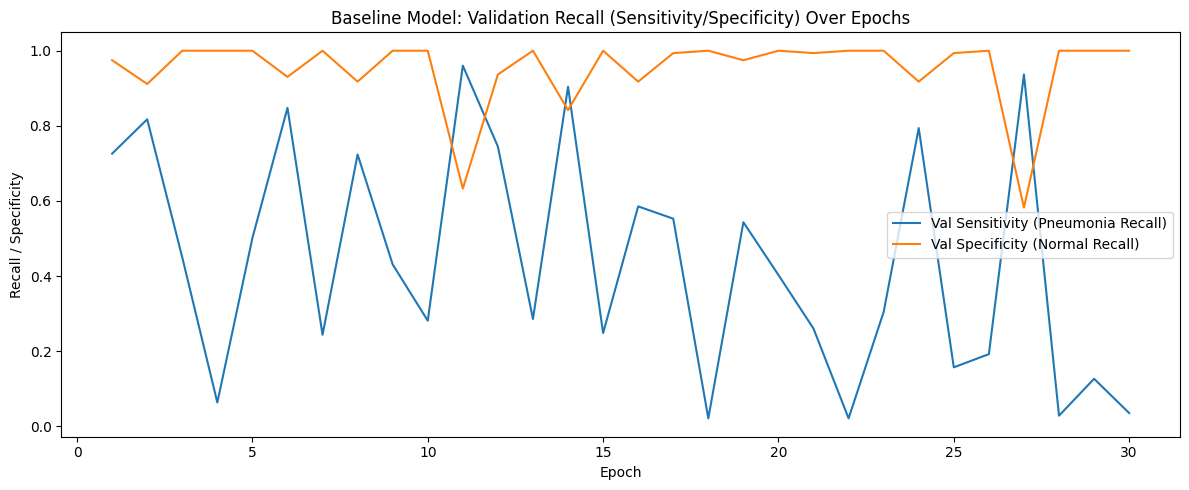

Model for Improvement 2 justification saved.


In [19]:
# Implement the experiment in as many cells as you need.

########################################################################
#                              YOUR CODE HERE                          #
########################################################################

# Photometric augmentation on simple baseline

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224

train_transform_imp2 = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),

    # Jittering contrast and brightness by up to 20%
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # Baseline Geometric Augmentation remains
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
])

train_dataset_imp2 = ChestXrayDataset(root_dir=dataset_path, split='train', transform=train_transform_imp2)
train_loader_imp2 = DataLoader(train_dataset_imp2, batch_size=batch_size, shuffle=True, num_workers=4)


# Initialise baseline model
model_imp2 = SimpleModel().to(device)

# define fixed LR, loss function and optimiser as before (no scheduler to keep consistency, only comparing to original baseline)
POS_WEIGHT_VAL = 0.3704
pos_weight_tensor = torch.tensor([POS_WEIGHT_VAL], dtype=torch.float32).to(device)
criterion_imp2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_imp2 = optim.Adam(model_imp2.parameters(), lr=1e-3)

# Training using original Q3 train_model
num_epochs_q43 = 30

# Setting wandb parameters
import wandb
wandb.init(project="COMP0188_CW1_Justification",
           name="Q4.3_Baseline_w_Augmentation",
           config={"model": "SimpleModel_ColorJitter",
                   "improvements": "ColorJitter Only"})

train_results_imp2 = train_model(
    model_imp2,
    train_loader_imp2,  # New data loader with augmentation
    val_loader,
    criterion_imp2,
    optimizer_imp2,
    num_epochs=num_epochs_q43,
    device=device,
    use_wandb=True
)

# Plotting and saving
plot_training_curves(
    train_results_imp2[0], train_results_imp2[1],
    train_results_imp2[2], train_results_imp2[3],
    train_results_imp2[4], train_results_imp2[5]
)

torch.save(train_results_imp2[-1], 'chest_xray_imp2_only_model.pth')
print("Model for Improvement 2 justification saved.")

## Option 1: Training with just Improvement 1 and Improvement 2, and comparing to final model

In [22]:
def train_model_scheduler_only(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20, device='cuda', use_wandb=True):
    """Trains the model while stepping the learning rate scheduler after each epoch."""

    wandb.init(project="COMP0188_CW1_Justification",
               name="Q4.4_Baseline_w_Scheduler",
               config={
                   "model": "SimpleModel_CosineLR",
                   "num_epochs": num_epochs,
                   "initial_lr": optimizer.param_groups[0]['lr'],
                   "scheduler": "CosineAnnealingLR"
               })
    wandb.watch(model, criterion, log="all", log_freq=10)

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    train_class_accuracies = {'Pneumonia_Recall': [], 'Normal_Recall': []}
    val_class_accuracies = {'Pneumonia_Recall': [], 'Normal_Recall': []}

    best_val_accuracy = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        tp, tn, fp, fn = 0, 0, 0, 0
        total_samples = 0

        # Training loop
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)"):
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Same metric calculation
            preds = torch.round(torch.sigmoid(outputs))
            labels_int = labels.int()
            preds_int = preds.int()

            tp += ((preds_int == 1) & (labels_int == 1)).sum().item()
            tn += ((preds_int == 0) & (labels_int == 0)).sum().item()
            fp += ((preds_int == 1) & (labels_int == 0)).sum().item()
            fn += ((preds_int == 0) & (labels_int == 1)).sum().item()

            total_samples += labels.size(0)


        # Scheduler step after each epoch completes
        scheduler.step()
        # Log current learning rate
        wandb.log({"Train/Learning_Rate": optimizer.param_groups[0]['lr']}, step=epoch)

        # Calculate epoch metrics
        epoch_loss = running_loss / total_samples
        epoch_accuracy = (tp + tn) / total_samples if total_samples > 0 else 0.0

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        train_class_accuracies['Pneumonia_Recall'].append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        train_class_accuracies['Normal_Recall'].append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)


        # Validation loop (same as Q3)
        model.eval()
        val_loss = 0.0
        val_tp, val_tn, val_fp, val_fn = 0, 0, 0, 0
        val_total_samples = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Val)"):
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                outputs = model(inputs)

                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                preds = torch.round(torch.sigmoid(outputs))
                labels_int = labels.int()
                preds_int = preds.int()

                val_tp += ((preds_int == 1) & (labels_int == 1)).sum().item()
                val_tn += ((preds_int == 0) & (labels_int == 0)).sum().item()
                val_fp += ((preds_int == 1) & (labels_int == 0)).sum().item()
                val_fn += ((preds_int == 0) & (labels_int == 1)).sum().item()

                val_total_samples += labels.size(0)

        epoch_val_loss = val_loss / val_total_samples
        epoch_val_accuracy = (val_tp + val_tn) / val_total_samples if val_total_samples > 0 else 0.0
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)
        val_pneumonia_recall = val_tp / (val_tp + val_fn) if (val_tp + val_fn) > 0 else 0.0
        val_normal_recall = val_tn / (val_tn + val_fp) if (val_tn + val_fp) > 0 else 0.0
        val_class_accuracies['Pneumonia_Recall'].append(val_pneumonia_recall)
        val_class_accuracies['Normal_Recall'].append(val_normal_recall)

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

        # logging to wandb
        wandb.log({
            "Train/Loss": epoch_loss,
            "Val/Loss": epoch_val_loss,
            "Val/Accuracy": epoch_val_accuracy,
            "Val/Pneumonia_Recall": val_pneumonia_recall,
            "Val/Normal_Recall": val_normal_recall
        })

        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy
            best_model_state = model.state_dict()

    wandb.finish()

    return train_losses, train_accuracies, val_losses, val_accuracies, train_class_accuracies, val_class_accuracies, best_model_state

In [23]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224
batch_size = 32

train_transform_ablation = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),


    # Just baseline geometric augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
])

train_dataset_ablation = ChestXrayDataset(root_dir=dataset_path, split='train', transform=train_transform_ablation)
train_loader_ablation = DataLoader(train_dataset_ablation, batch_size=batch_size, shuffle=True, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.04it/s]


Epoch 1/30: Train Loss: 0.1792, Train Acc: 0.8582, Val Loss: 0.1379, Val Acc: 0.9402, LR: 0.000997


Epoch 2/30 (Train):   0%|          | 0/147 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 2/30 (Val): 100%|██████████| 19/19 [00:07<00:00,  2.42it/s]


Epoch 2/30: Train Loss: 0.1400, Train Acc: 0.8933, Val Loss: 0.0894, Val Acc: 0.9419, LR: 0.000989


Epoch 3/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.03it/s]


...

Epoch 29/30 (Val): 100%|██████████| 19/19 [00:08<00:00,  2.16it/s]


Epoch 29/30: Train Loss: 0.0446, Train Acc: 0.9731, Val Loss: 0.0371, Val Acc: 0.9675, LR: 0.000003


Epoch 30/30 (Val): 100%|██████████| 19/19 [00:09<00:00,  2.02it/s]

Epoch 30/30: Train Loss: 0.0448, Train Acc: 0.9686, Val Loss: 0.0378, Val Acc: 0.9675, LR: 0.000000


Train/Learning_Rate,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
Train/Loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
Val/Accuracy,▇▇▁▇█▇▇██▇▄██▇█▇██████████████
Val/Loss,▂▂█▂▂▂▂▁▁▂▆▁▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
Val/Normal_Recall,▂▇█▃▆▁▃▇▇██▇▅█▄█▇▄████▇█▇█████
Val/Pneumonia_Recall,█▇▁█████▇▇▃██▇█▇████▇▇████████
Train/Learning_Rate,0
Train/Loss,0.04484
Val/Accuracy,0.96752
Val/Loss,0.03783
Val/Normal_Recall,0.98734


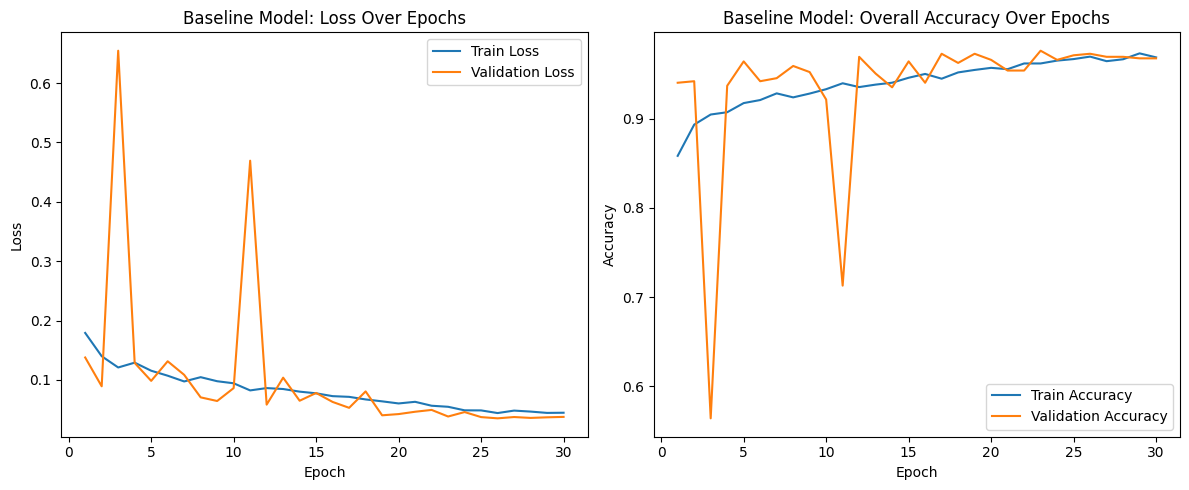

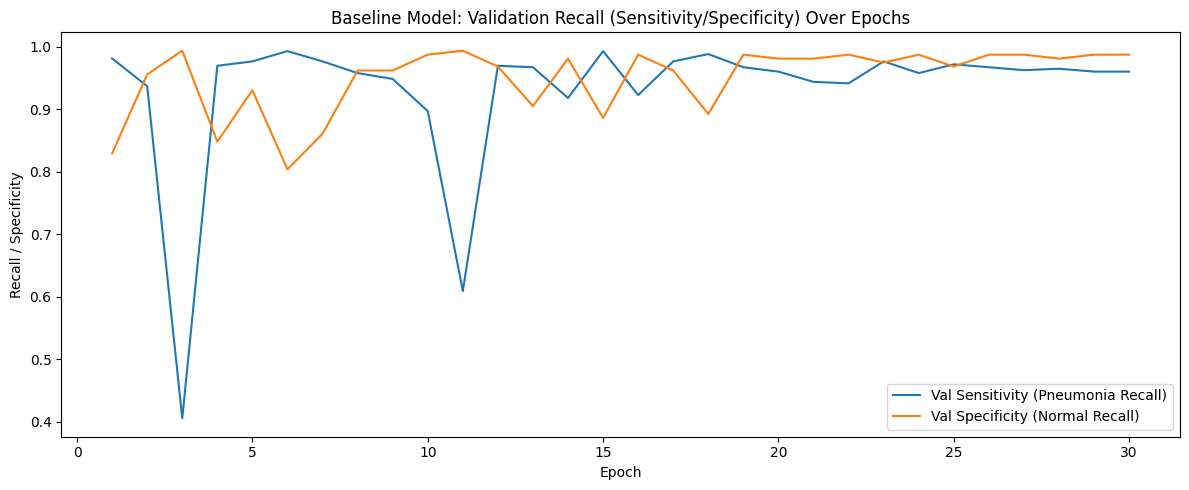

Model for Improvement 2 ablation justification saved.


In [24]:
# Initialize Resnet model (Improvement 1)
model_ablation = ResNetModel().to(device)

# Weighted loss and adam
POS_WEIGHT_VAL = 0.3704
pos_weight_tensor = torch.tensor([POS_WEIGHT_VAL], dtype=torch.float32).to(device)
criterion_ablation = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_ablation = optim.Adam(model_ablation.parameters(), lr=1e-3)

# Defining cosine annealing scheduler (improvement 2)
num_epochs_q43 = 30
scheduler_ablation = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ablation, T_max=num_epochs_q43)

import wandb
wandb.init(project="COMP0188_CW1_Justification",
           name="Q4.3_Ablation_NO_Augmentation",
           config={"model": "ResNet_NoJitter_CosineLR",
                   "improvements": "ResNet + CosineLR Only"})

train_results_ablation = train_model_scheduler_only(
    model_ablation,
    train_loader_ablation,
    val_loader,
    criterion_ablation,
    optimizer_ablation,
    scheduler_ablation,
    num_epochs=num_epochs_q43,
    device=device,
    use_wandb=True
)

plot_training_curves(
    train_results_ablation[0], train_results_ablation[1],
    train_results_ablation[2], train_results_ablation[3],
    train_results_ablation[4], train_results_ablation[5]
)

best_model_state_ablation = train_results_ablation[-1]
torch.save(best_model_state_ablation, 'chest_xray_imp2_ablation_model.pth')
print("Model for Improvement 2 ablation justification saved.")

**(a)**

**Photometric Augmentation:**  The model is overfitting to artefacts in the images that do not have medical meaning; introduction of further, photometric data augmentation techniques can improve the resilience of the model to variations in contrast or brightness. Option 2 is used to first identify whether the baseline model is overfitting, and then Option 1 is employed analyse the effect of training set augmentation on the improved model, as well as to evaluate whether the improved model is more generalisable and robust to variations in image characteristics.

**(b) Results:**


_Table 5. Performance metrics on validation set for training baseline model with additional photometric augmentation (Option 2)._

| Metric                          | Improvement 3 | Baseline |
|---------------------------------|--------------|----------------|
| Accuracy                        | 0.29573      | 0.93333        |
| Loss                            | 2.01915      | 0.08757        |
| Normal Recall (Specificity)     | 1.00000      | 0.94937        |
| Pneumonia Recall (Sensitivity)  | 0.03513      | 0.9274         |

_Figure 11. Loss and accuracy curves of training baseline model with additional photometric augmentation (Option 2)._

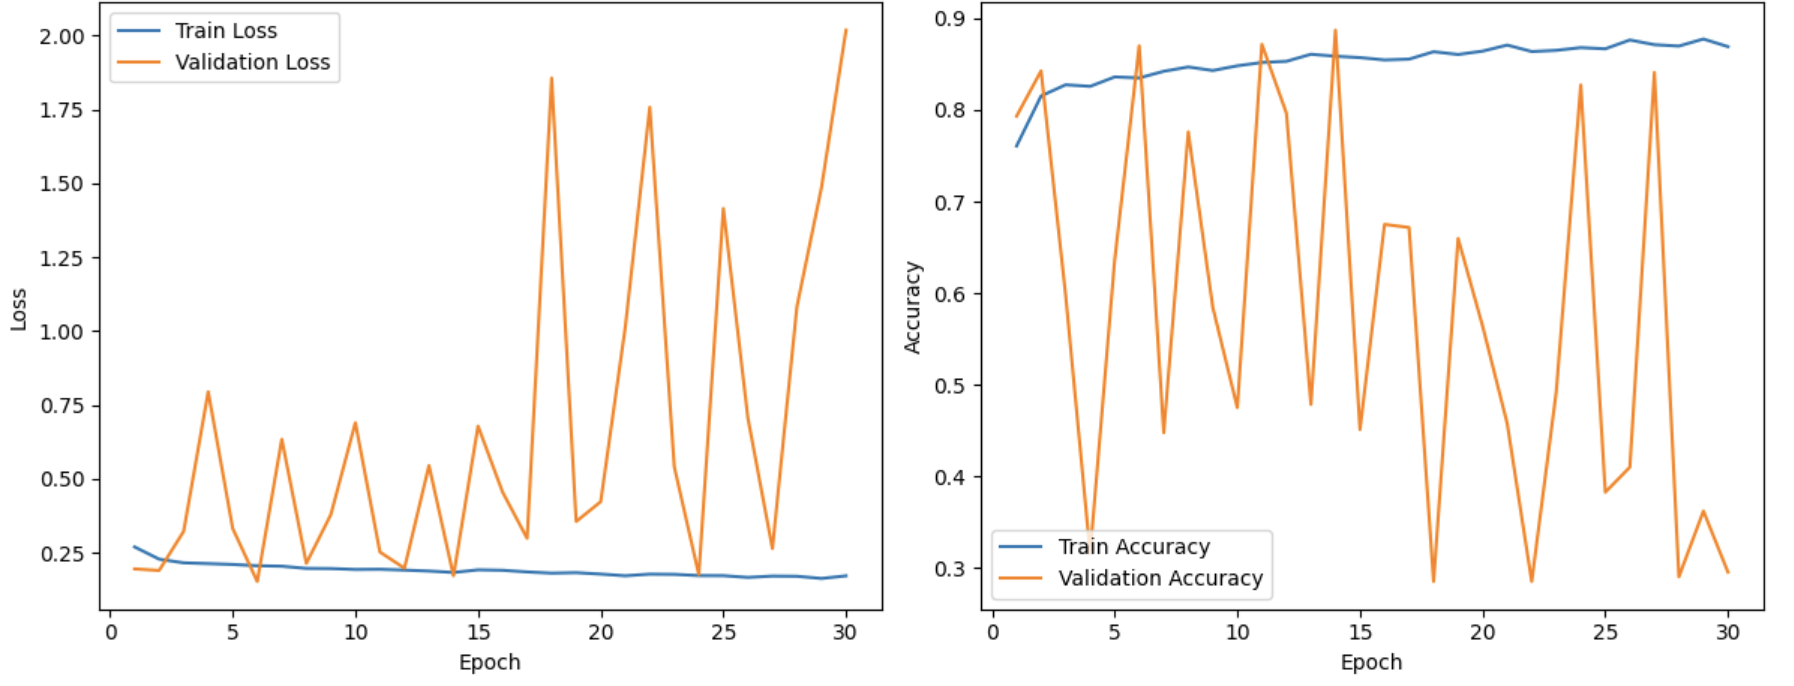

_Figure 12. Plot of specificity and sensitivity for Option 2._

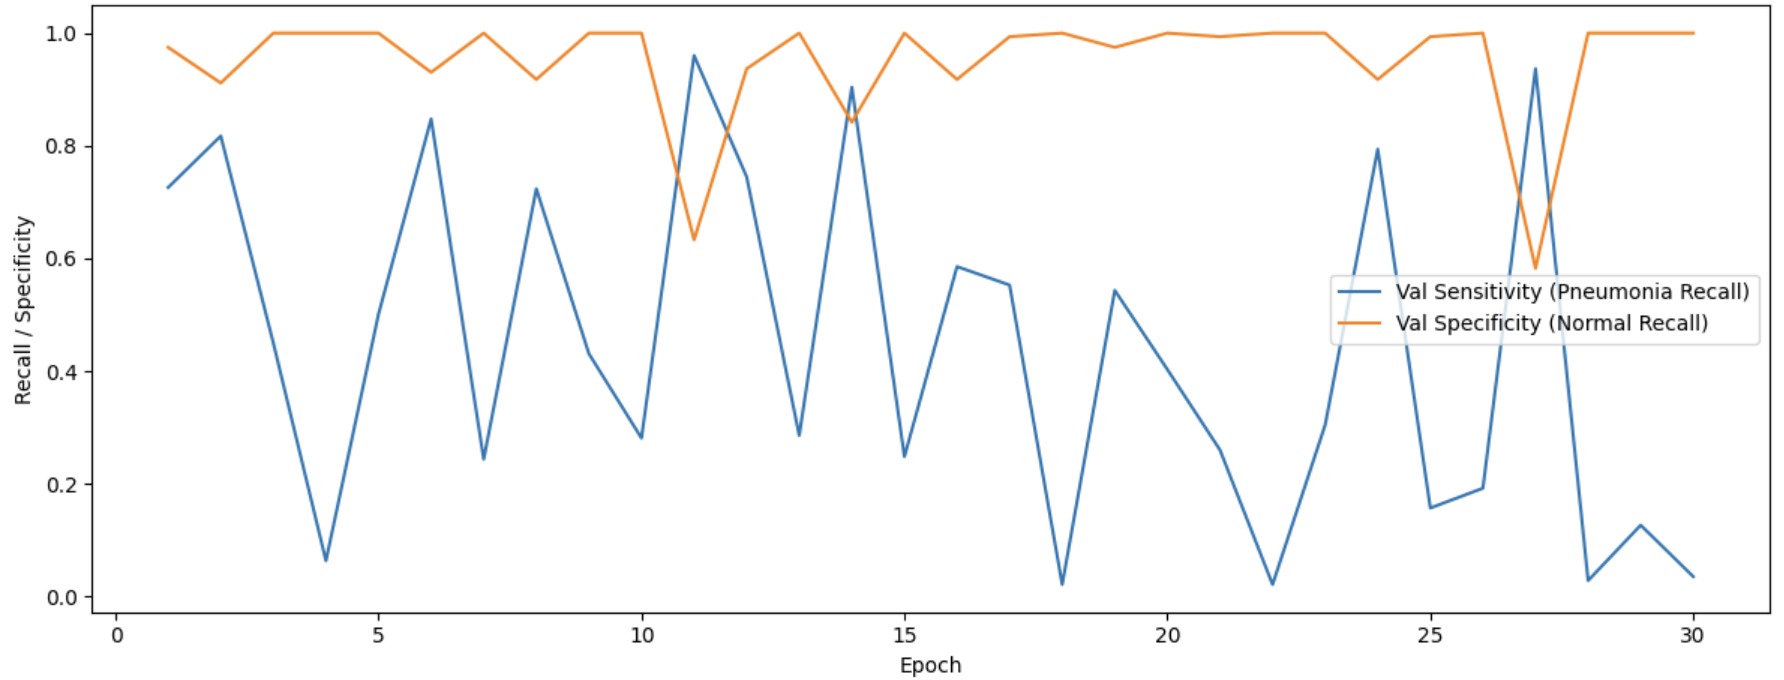


_Table 6. Improved model performance with and without photometric augmentation._

| Metrics (Validation) | With    | Without |
|----------------------|---------|---------|
| Accuracy             | 0.94530 | 0.96752 |
| Loss                 | 0.08352 | 0.03783 |
| Specificity          | 0.96203 | 0.98734 |
| Sensitivity          | 0.93911 | 0.96019 |


_Figure 13. Comparison of loss and accuracy curves for improved model (a) without and (b) with photometric augmentation._

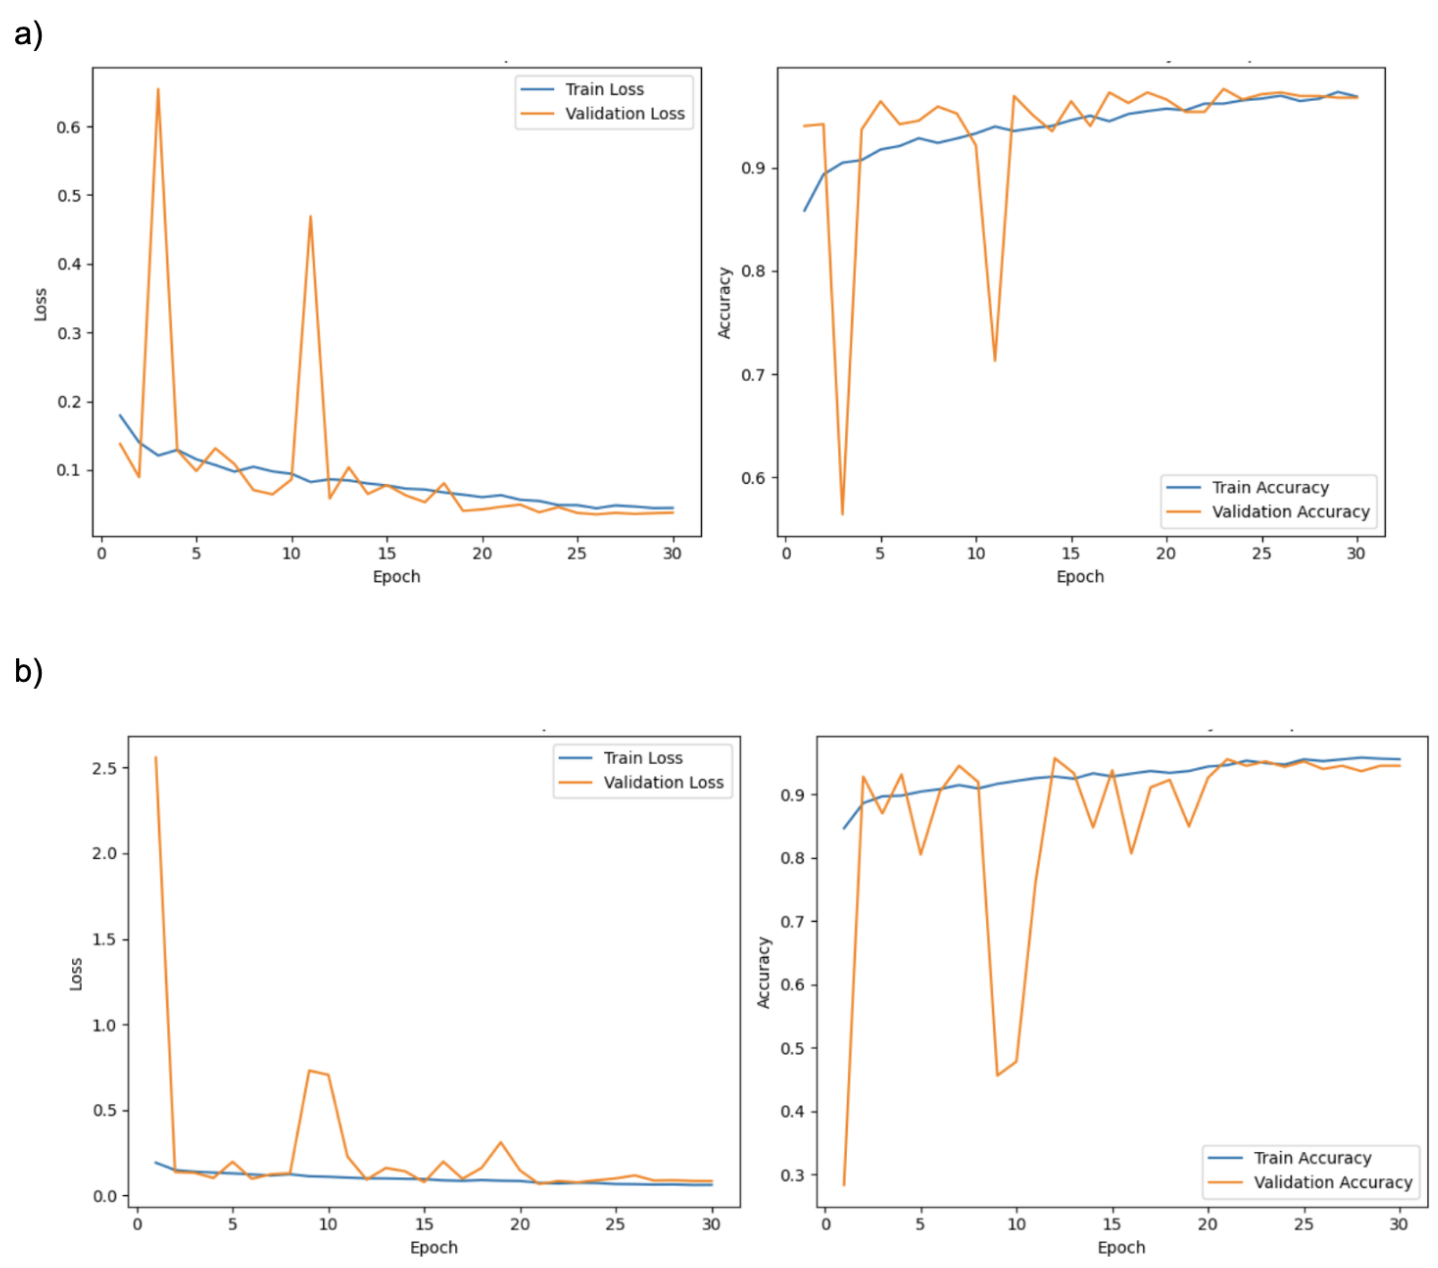

_Figure 14. Comparison of variation in validation specificity and sensitivity against number of epochs for for improved model (a) without and (b) with photometric augmentation._

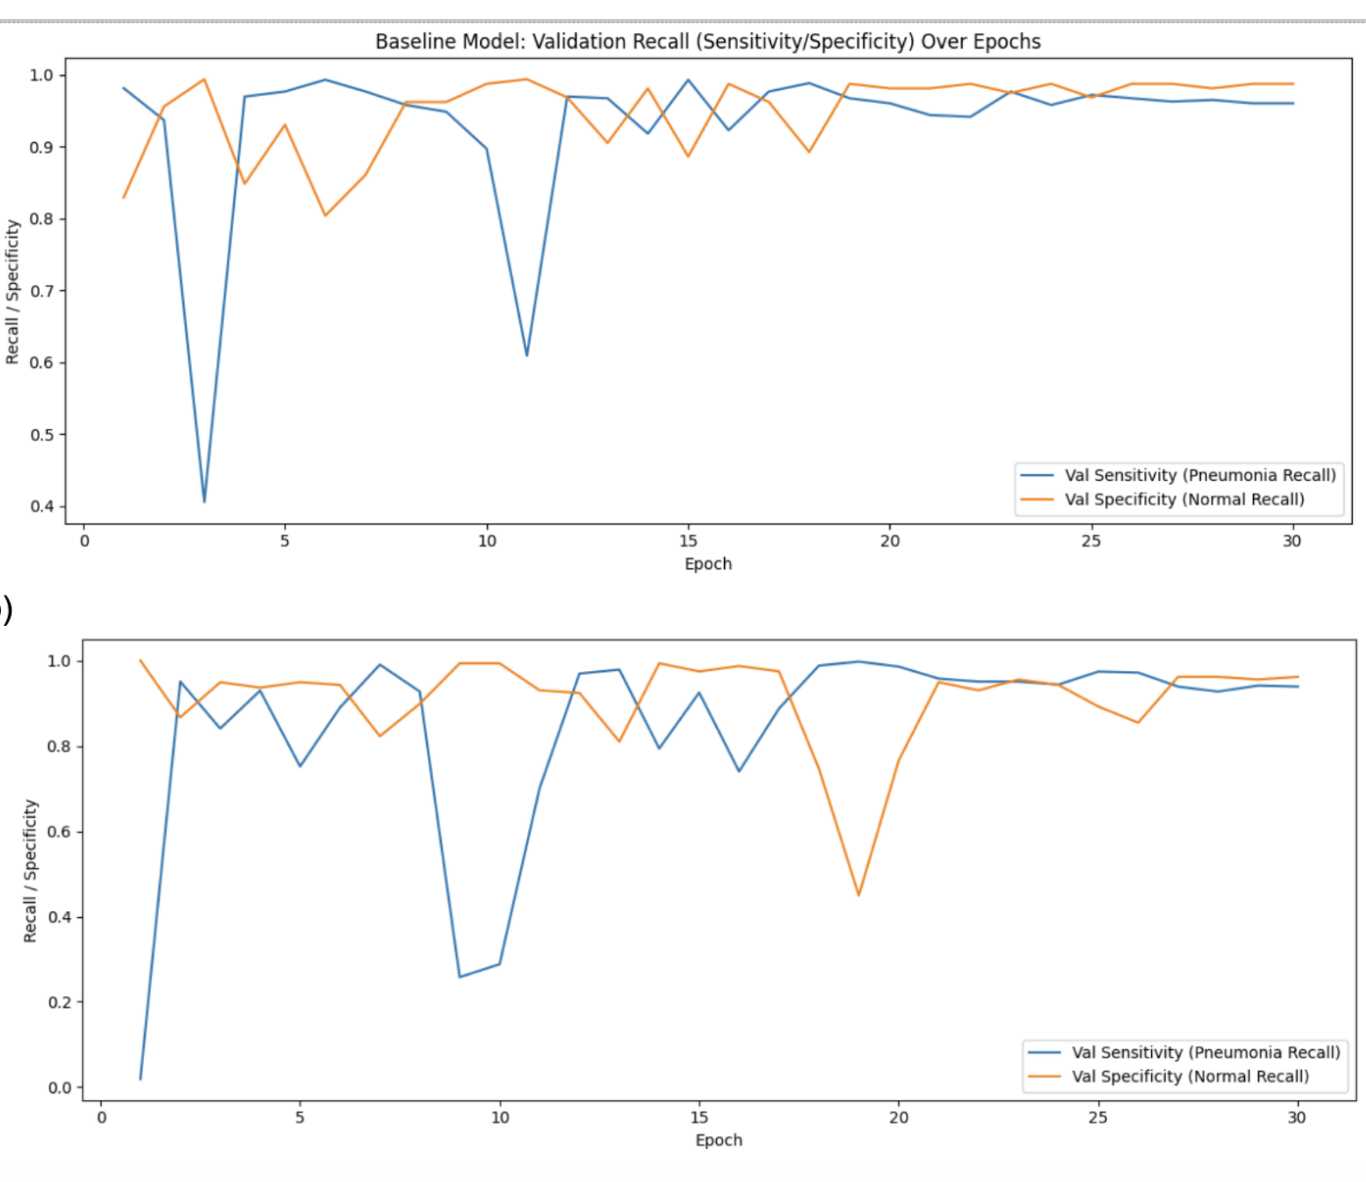

**(c) Discussion:**

To detect whether the model is overfitting to artefacts specific to this set of X-ray images and to analyse the true generalisability of the model, ColorJitter is employed in preprocessing and the baseline is rerun.

Accuracy drops from 93.33% to 29.57%, and loss shoots up to 2.019 from 0.0876 (Table 5), with the model completely failing on the PNEUMONIA class (Sensitivity = 0.03513). Figure 11 and 12 demonstrate the extreme instability in validation accuracy, loss, and sensitivity.

These results strongly suggest that the strong performance of the baseline model may indeed be partially due to overfitting to the specific image characteristics of the dataset rather than effectively identifying the high-level medical meanings of the images. This renders the model relatively useless in a clinical setting, only performing well if the exact X-ray machine and settings used in the Kermany dataset are being used there.

These results show that augmentation techniques such as jittering should be included in the preprocessing for the final model to support robustness and better generalisation, as well as acting as a check on whether the model is overfitting.

Regarding the latter, I then use Option 1 to test the generalisability of the improved model (ResNet architecture and cosine annealing). Table 6 compares the results of the improved model with and without photometric augmentation. Introduction of this augmentation only leads to a reduction in accuracy of 2.04% (from 96.75% to 94.53%), far lower than the 63.76% reduction observed when this augmentation is applied to the baseline model. Figure 13 and 14 also show that speed of convergence is only slightly affected by the extra complexity of the augmentation.

Two main conclusions can be drawn from these analyses:

(a) Inclusion of photometric augmentation in preprocessing is important for both improving and verifying robustness of models to variations in image characteristics such as brightness and contrast.

(b) The improved model shows excellent robustness compared to the baseline when jittering is implemented into training.

# Question 5: Final Evaluation (10 marks)

You should perform a final evaluation of the performance of your model


In [29]:
# Implement evaluation here

########################################################################
#                              YOUR CODE HERE                          #
########################################################################

import os
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from tqdm import tqdm

# Defining Test transforms (resizing and normalization only)
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Using 'test' split
test_dataset = ChestXrayDataset(root_dir=dataset_path, split='test', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_test_set(model, test_loader, criterion, device):
    """
    Evaluates the model on the test set and calculates final metrics,
    including the Confusion Matrix components.
    """
    model.eval()
    test_loss = 0.0
    val_tp, val_tn, val_fp, val_fn = 0, 0, 0, 0
    test_total_samples = 0

    # Storing all predicted and true labels for matrix plotting
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating Test Set"):
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(inputs)

            # Loss calculation
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            # Metric calculation
            preds = torch.round(torch.sigmoid(outputs))
            labels_int = labels.int()
            preds_int = preds.int()

            val_tp += ((preds_int == 1) & (labels_int == 1)).sum().item()
            val_tn += ((preds_int == 0) & (labels_int == 0)).sum().item()
            val_fp += ((preds_int == 1) & (labels_int == 0)).sum().item()
            val_fn += ((preds_int == 0) & (labels_int == 1)).sum().item()

            test_total_samples += labels.size(0)

            # Store results for Confusion Matrix plotting
            all_preds.extend(preds_int.cpu().numpy().flatten())
            all_labels.extend(labels_int.cpu().numpy().flatten())


    # Final Metric calculation
    final_test_loss = test_loss / test_total_samples
    final_test_accuracy = (val_tp + val_tn) / test_total_samples

    # Recall / Specificity / Precision
    recall_pneumonia = val_tp / (val_tp + val_fn) if (val_tp + val_fn) > 0 else 0.0 # Sensitivity
    recall_normal = val_tn / (val_tn + val_fp) if (val_tn + val_fp) > 0 else 0.0     # Specificity

    # Precision (Positive Predictive Value)
    precision_pneumonia = val_tp / (val_tp + val_fp) if (val_tp + val_fp) > 0 else 0.0


    # --- Confusion Matrix Plotting ---

    # Create the matrix: [[TN, FP], [FN, TP]]
    cm = np.array([[val_tn, val_fp],
                   [val_fn, val_tp]])

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    # Set class labels (0=Normal, 1=Pneumonia)
    classes = ['NORMAL (0)', 'PNEUMONIA (1)']
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title='Final Test Set Confusion Matrix',
           ylabel='True label',
           xlabel='Predicted label')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    fmt = 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    plt.show() # Display the confusion matrix plot

    return {
        'Loss': final_test_loss,
        'Accuracy': final_test_accuracy,
        'Sensitivity (Pneumonia Recall)': recall_pneumonia,
        'Specificity (Normal Recall)': recall_normal,
        'Precision (Pneumonia)': precision_pneumonia
    }

Evaluating Test Set: 100%|██████████| 19/19 [00:09<00:00,  2.02it/s]


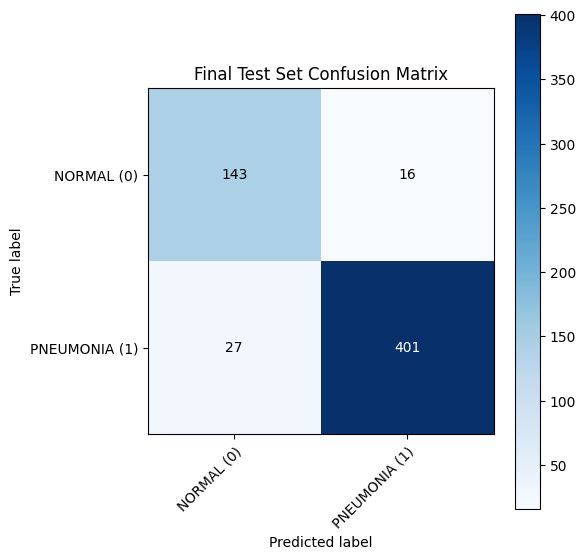

Test Loss                           : 0.1168
Overall Test Accuracy               : 0.9267
Class-Specific Accuracies:
Pneumonia Recall (Sensitivity)      : 0.9369
Normal Recall (Specificity)         : 0.8994
Pneumonia Precision (PPV)           : 0.9616


In [31]:
final_model = ResNetModel().to(device)

# Loading best trained weights from Q4.1
model_path = 'chest_xray_final_model.pth'
final_model.load_state_dict(torch.load(model_path, map_location=device))

pos_weight_tensor = torch.tensor([POS_WEIGHT_VAL], dtype=torch.float32).to(device)
final_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

final_test_metrics = evaluate_test_set(final_model, test_loader, final_criterion, device)

# Print overall metrics
print(f"{'Test Loss':<35} : {final_test_metrics['Loss']:.4f}")
print(f"{'Overall Test Accuracy':<35} : {final_test_metrics['Accuracy']:.4f}")

# Print Class-Specific Accuracies (Recall/Specificity)
print("Class-Specific Accuracies:")
print(f"{'Pneumonia Recall (Sensitivity)':<35} : {final_test_metrics['Sensitivity (Pneumonia Recall)']:.4f}")
print(f"{'Normal Recall (Specificity)':<35} : {final_test_metrics['Specificity (Normal Recall)']:.4f}")
print(f"{'Pneumonia Precision (PPV)':<35} : {final_test_metrics['Precision (Pneumonia)']:.4f}")

**(a) Results:**

_Table 7. Comparison of valdation and test performance for baseline and final model._

| Metric                     | Baseline | Final Model |
|----------------------------|----------|-------------|
| Validation Accuracy        | 0.93333  | 0.94530    |
| Validation Loss            | 0.08757  | 0.08352    |
| Validation Specificity     | 0.94937  | 0.96203    |
| Validation Sensitivity     | 0.92740  | 0.93911    |
| Test Accuracy              | 0.91310  | 0.92670    |
| Test Loss                  | 0.14030  | 0.11680    |
| Test Specificity           | 0.89310  | 0.89940    |
| Test Sensitivity           | 0.92060  | 0.93690    |

_Figure 15. Comparing Loss (left) and Accuracy (right) stability of Baseline (a) and Final (b) Models._
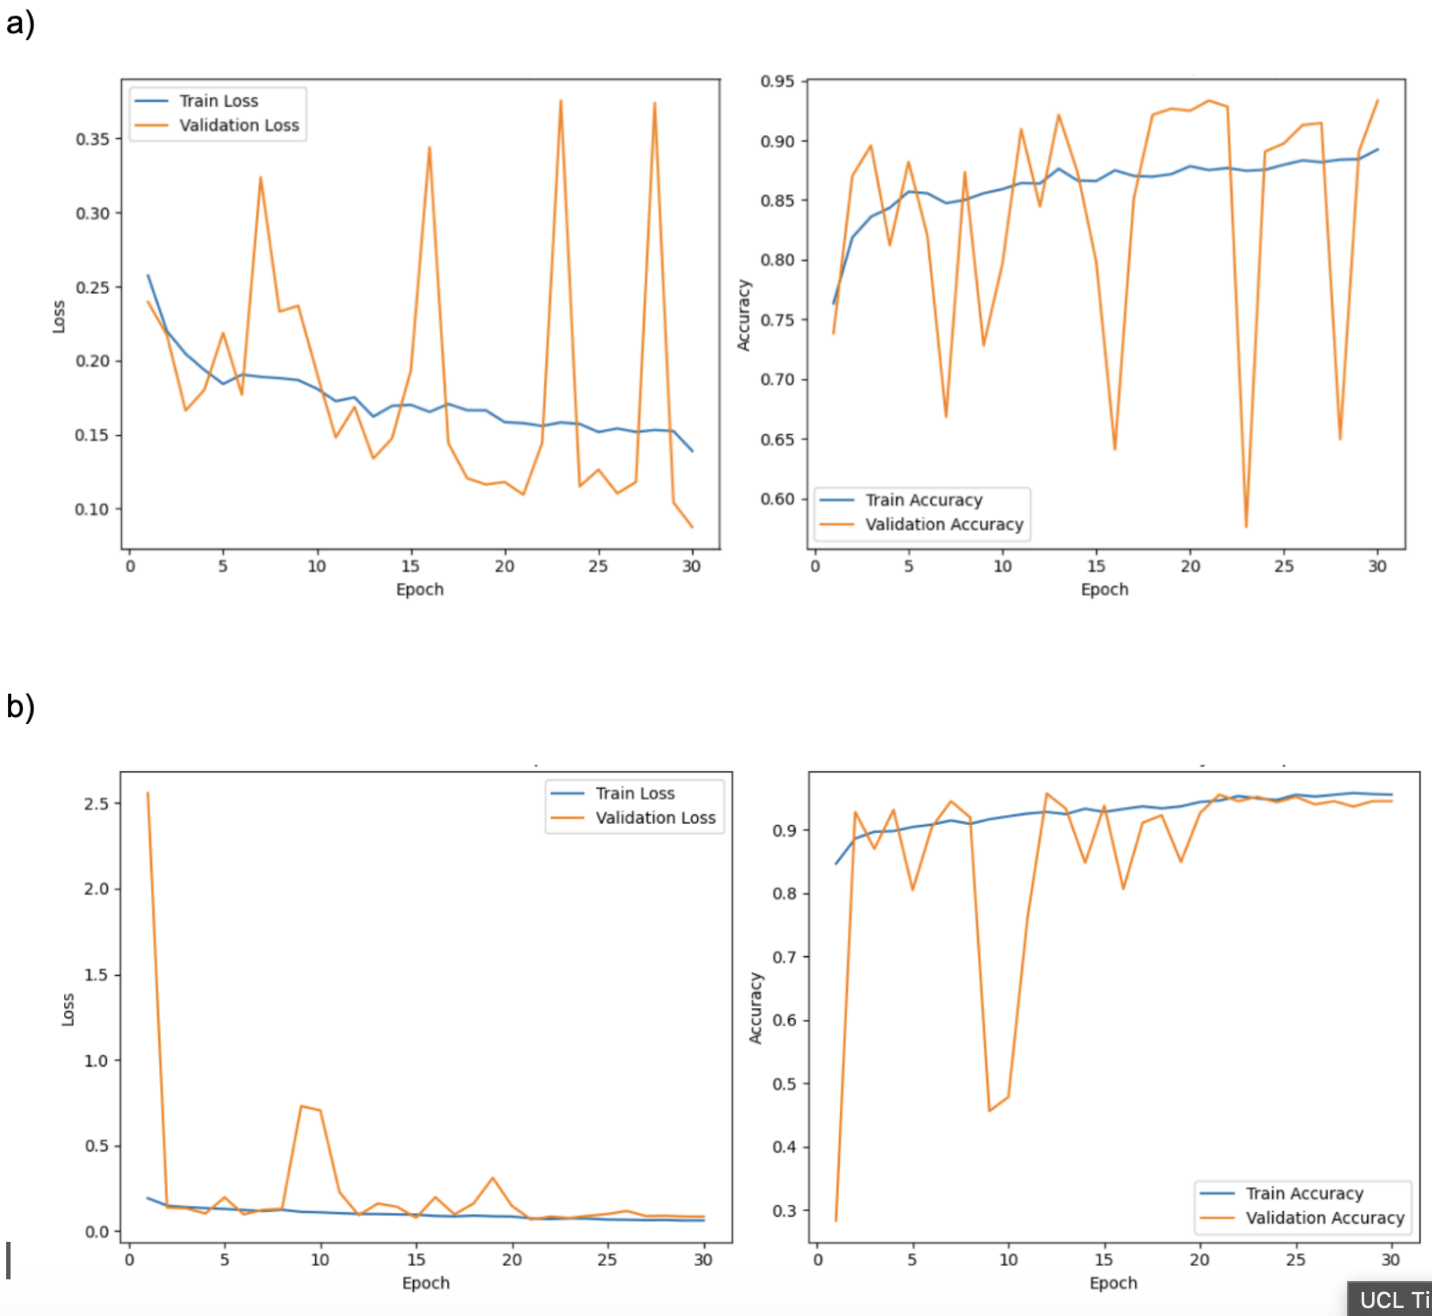



_Figure 16. Comparing Specificity and Sensitivity stability of Baseline (a) and Final (b) Models._

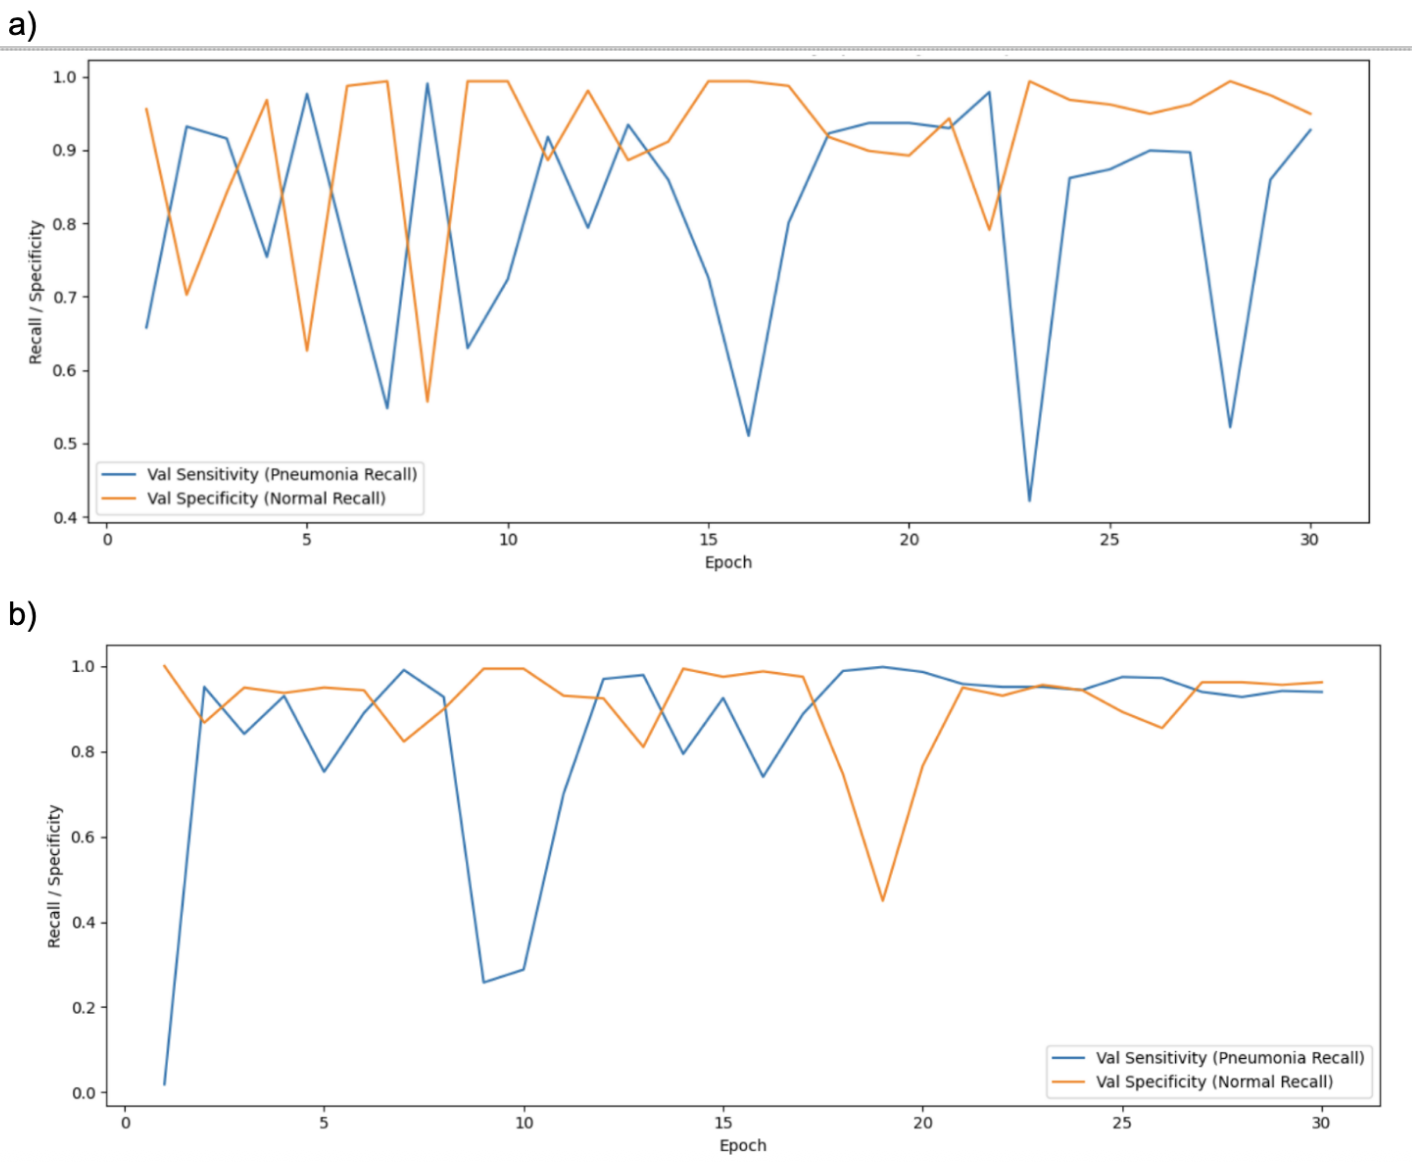

_Figure 17. Comparing confusion matrices for Baseline (a) and Final (b) models._

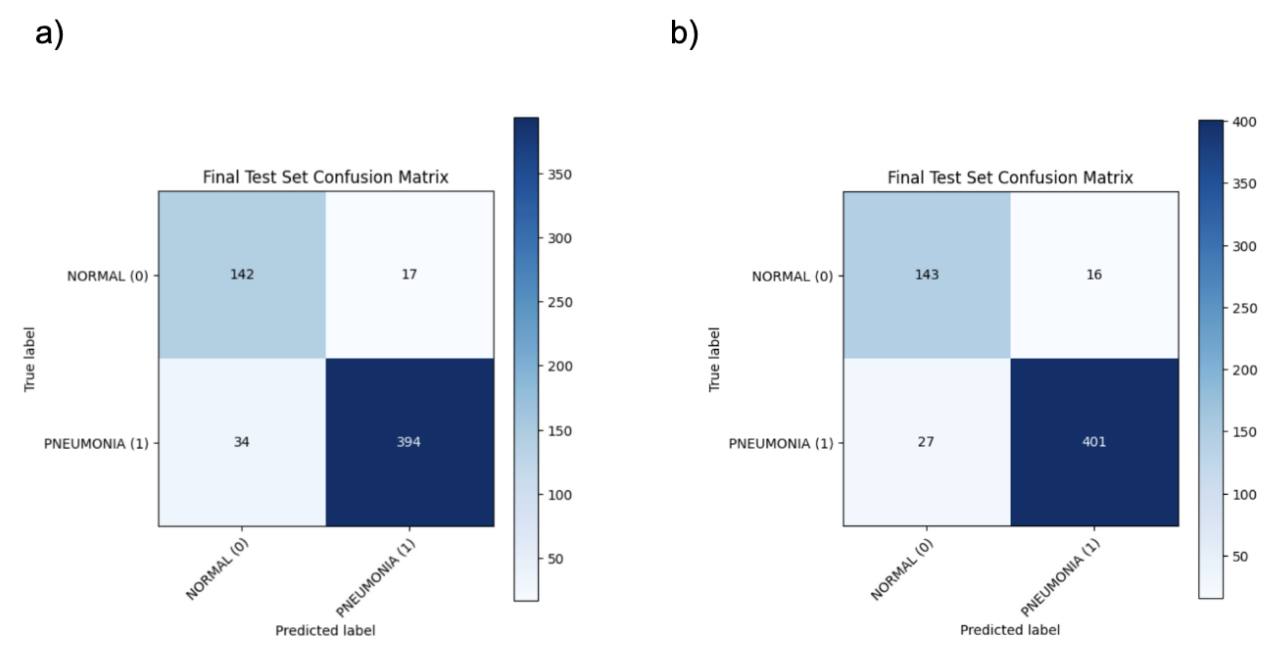

**(b)**

Table 7 demonstrates that the final model outperforms the baseline on all metrics for both the validation and test sets after 30 epochs of training. Via a confusion matrix, Figure 17 demonstrates that final model reducing the number of misclassified PNEUMONIA samples from 34 to 27 and the number of misclassified NORMAL samples from 17 to 16. This 20.6% reduction is false negatives (which is essential in the context of pneumonia - false negatives are generally more dangerous than false positives) is likely a result of the increased feature capacity provided by the Mini-ResNet architecture.

Simultaneously, the final model is more robust to variations in image characteristics (contrast, brightness) due to introduction of ColorJitter in preprocessing and the increased depth of the Residual Network model, and is observed to not overfit to these characteristics, in contrast to the baseline model (Q4.4).

It can clearly be argued that the photometric augmentation harms performance on the Kermany dataset (it reduces validation accuracy by 2.04% (Table 6), from the 96.75% achieved with Improvements 1+2). If the goal is to optimise performance on this specific set of medical images, such augmentation should not be applied. However, I would argue that a model that is not generalisable across and robust to differences in imaging equipment or patient demographics (in this dataset, images are only of patients aged 1 to 5) is not as useful in a medical context as one that is. As such, I find that, in the case of training on a dataset from one institution (likely using the same equipment) and on a narrow demographic, the application of photometric augmentation techniques such as jittering to the training set is important to both improve and verify generalisability.

Finally, addressing perhaps the biggest issue with the baseline, the final model is far more stable and better at generalising than the baseline: validation accuracy and loss stabilise at approximately epoch 21 for the improved model, but fail to stably converge for the baseline (Figures 15 and 16). This can be attributed to the introduction of cosine annealing learning rate scheduling.

Overall, a test-set accuracy of 92.67% is achieved, with a specificity of 89.31% and a sensitivity of 93.69%. This is comparable to the original literature, with Kermany et al. (2018) achieving an accuracy of 92.8%, with a
sensitivity of 93.2% and a specificity of 90.1%.[1]

Further improvements of this final model should prioritise greater reductions in the number of false negatives and evaluation of performance across different demographic subgroups and on X-ray images that used different equipment and/or image processing configurations.

[1] Kermany, D.S. et al. (2018) 'Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning', Cell, 172(5), pp. 1122–1131.e9. doi: 10.1016/j.cell.2018.02.010.